In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy
import ast
import os
import glob
import matplotlib as mpl
from tqdm import tqdm
from scipy.special import kl_div, rel_entr
from scipy.spatial.distance import jensenshannon
import random
import warnings

In [2]:
def get_csv_filenames(directory):
    return [f for f in os.listdir(directory) if f.endswith('.csv') and os.path.isfile(os.path.join(directory, f))]

def get_df(loc):
    dfs = []
    names = []

    combined = pd.DataFrame()

    for file in get_csv_filenames(loc):
        df = pd.read_csv(f'{loc}/{file}', index_col='Unnamed: 0')
        df['model'] = file.split('.pkl')[0].lower()
        df['params'] = int(file.split('B')[0].split('-')[-1])
        df['question_num'] = df.index
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True).reset_index(drop=True)

def minmaxNorm(df):
    return (df-df.min())/(df.max()-df.min())

def stdNorm(df):
    return (df-df.mean())/df.std()

def norm_ent(probs):
    return scipy.stats.entropy(probs) / np.log(len(probs))

def get_most_populace_answers(df):
    # get largest value and index in each list in df['Answers']
    df['most_popular_answer'] = df['Answer_Ratios'].apply(lambda x: max(x))
    df['most popular answer index'] = df['Answer_Ratios'].apply(lambda x: x.index(max(x)))
    # convert index to a letter A through Z
    df['Answer'] = df['most popular answer index'].apply(lambda x: str(chr(65+x)))
    return df

def pre_process_align(df):
    new_df = df.copy()
    try: # iroper
        new_df['Answer_Ratios'] = new_df['Answer_Ratios'].apply(lambda x: ast.literal_eval(x))
    except: # pew
        # fix formatting errors from opening in excel before experiments
        new_df.loc[new_df['answer ratios'] == '6/25/1969', 'answer ratios'] = '6-25-69'
        new_df.loc[new_df['answer ratios'] == '3/11/1986', 'answer ratios'] = '3-11-86'

        new_df['Answer_Ratios'] = new_df['answer ratios'].apply(lambda x: [int(i) for i in x.split('-')])
        new_df.drop(['answer ratios'], axis=1, inplace=True)

    new_df['choice-probs'] = new_df['choice-probs'].apply(lambda x: ast.literal_eval(x))
    new_df['Answer_Ratio_probs'] = new_df['Answer_Ratios'].apply(lambda x: np.array(x)/sum(x))
    new_df['human c-ent'] = new_df['Answer_Ratio_probs'].apply(lambda x: scipy.stats.entropy(x))
    new_df['human c-ent-norm'] = new_df['Answer_Ratio_probs'].apply(lambda x: norm_ent(x))

    # reference answer is most commonly chosen choice (converted to alphabetical label)
    new_df['ref_answer'] = new_df['Answer_Ratios'].apply(lambda x: str(chr(65 + x.index(max(x)))))
    new_df['mod_agrees'] = new_df['ref_answer'] == new_df['model output']

    # remove invalid rows. Only detected rows this affects is due to >26 choices.
    invalid_rows = new_df['choice-probs'].apply(lambda x: len(x)) != new_df['Answer_Ratios'].apply(lambda x: len(x))
    new_df = new_df[~(invalid_rows)].reset_index(drop=True)
    print(f'Removed {len(invalid_rows[invalid_rows])} invalid rows')

    return new_df

def pre_process_calib(df):
    new_df = df.copy()
    new_df['choice-probs'] = new_df['choice-probs'].apply(lambda x: ast.literal_eval(x))
    new_df['ref_answer'] = new_df['Answers']
    new_df['mod_agrees'] = new_df['ref_answer'] == new_df['model output']

    return new_df


In [3]:
iroper_df = get_df('iroper/')
mmlu_df = get_df('mmlu/')
pew_df = get_df('pew/')

In [4]:
iroper_proc_df = pre_process_align(iroper_df)
pew_proc_df = pre_process_align(pew_df)

mmlu_proc_df = pre_process_calib(mmlu_df)

Removed 20 invalid rows
Removed 0 invalid rows


In [5]:
iroper_proc_df[iroper_proc_df['model'] == iroper_proc_df['model'].unique()[0]]['Answer_Ratios'].apply(lambda x: len(x)).mean()

np.float64(3.7725150100066713)

In [6]:
ent_measures = [
 'choice-ent',
 'top-1-abs',
 'total-ent',

 'top-k-ent-5',
 'top-k-ent-10',
 'top-k-ent-25',
 'top-k-ent-50',

 'top-k-ent-100',
 'top-p-len-0.95',
 'top-p-ent-0.95',
 'top-p-len-0.9',

 'top-p-ent-0.9',
 'top-p-len-0.75',
 'top-p-ent-0.75',
 'top-p-len-0.5',

 'top-p-ent-0.5',
 ]

def check_measures(df):
    for measure in ent_measures:
        if measure.startswith('top-p-len'):
            if not df[measure].apply(lambda x: isinstance(x, int)).all():
                print(f'Failed on measure {measure}')
        else:
            if not df[measure].apply(lambda x: isinstance(x, float)).all():
                print(f'Failed on measure {measure}')
    print('Finished')


In [7]:
print('iroper')
check_measures(iroper_proc_df)
print('mmlu')
check_measures(mmlu_proc_df)
print('pew')
check_measures(pew_proc_df)


iroper
Finished
mmlu
Finished
pew
Finished


## Alignment

In [8]:
for model in iroper_proc_df['model'].unique():
    tmp_df = iroper_proc_df[iroper_proc_df['model'] == model]

    print(f'actual ({model})', len(tmp_df[tmp_df['mod_agrees']]) / len(tmp_df['mod_agrees']))

print('expected', 1 / iroper_proc_df['Answer_Ratios'].apply(lambda x: len(x)).mean())
print('samples', len(tmp_df['Answer_Ratios']))


actual (mistralai-mistral-7b-instruct-v0.1) 0.35957304869913276
actual (meta-llama-llama-3.1-8b) 0.3619079386257505
actual (meta-llama-llama-3.2-1b-instruct) 0.31287525016677786
actual (mistralai-mistral-7b-v0.3) 0.35023348899266177
actual (meta-llama-llama-3.1-8b-instruct) 0.4269513008672448
actual (meta-llama-llama-3.2-1b) 0.2705136757838559
actual (mistralai-mistral-7b-instruct-v0.3) 0.39192795196797864
actual (mistralai-mistral-7b-v0.1) 0.3458972648432288
actual (meta-llama-llama-3.2-3b-instruct) 0.37191460973982654
actual (meta-llama-llama-3.2-3b) 0.319212808539026
expected 0.2650751547303271
samples 2998


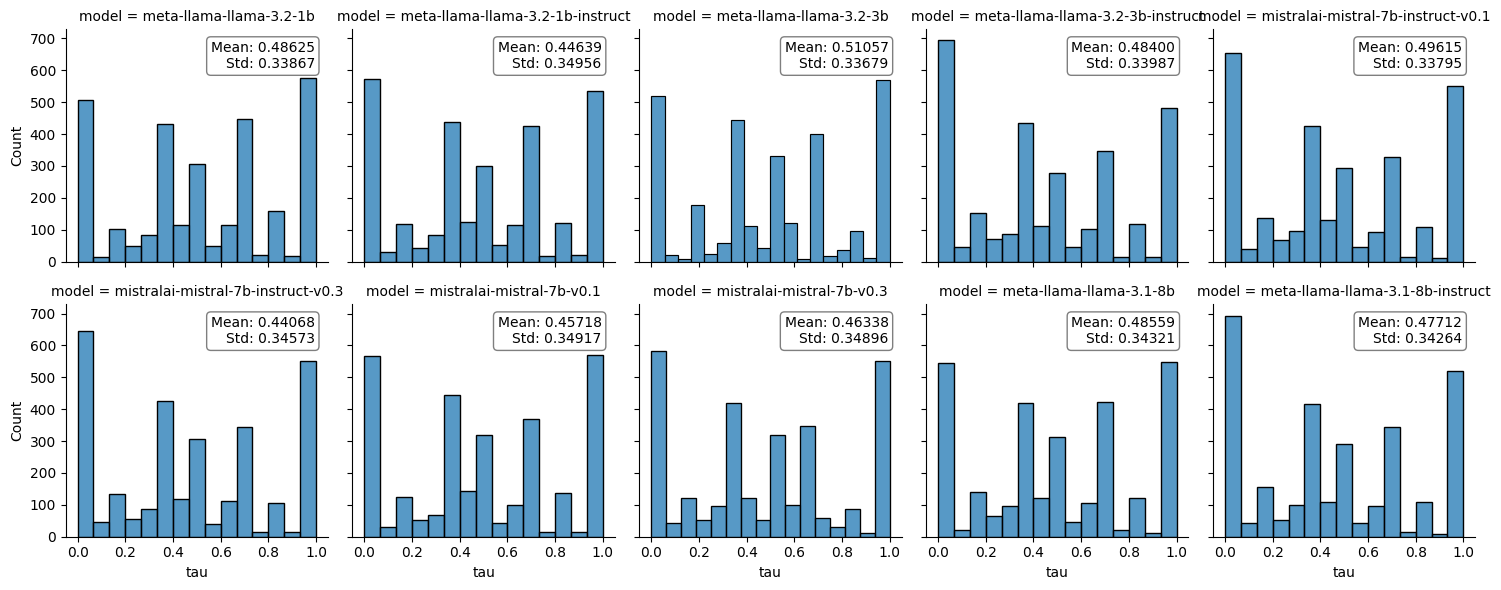

In [ ]:
def normalised_kendall_tau_distance(values1, values2):
    """Compute the Kendall tau distance."""
    n = len(values1)
    assert len(values2) == n, "Both lists have to be of equal length"
    i, j = np.meshgrid(np.arange(n), np.arange(n))
    a = np.argsort(values1)
    b = np.argsort(values2)
    ndisordered = np.logical_or(np.logical_and(a[i] < a[j], b[i] > b[j]), np.logical_and(a[i] > a[j], b[i] < b[j])).sum()
    return ndisordered / (n * (n - 1))

tmp_df = iroper_proc_df.copy()
tmp_df['Answer_Ratios_norm'] = tmp_df['Answer_Ratios'].apply(lambda x: [x_i / sum(x) for x_i in x])
tmp_df['choice-probs_norm'] = tmp_df['choice-probs'].apply(lambda x: [x_i / sum(x) for x_i in x])

tmp_df = tmp_df.sort_values(['params', 'model'], ascending=True)

output_df = pd.DataFrame()
for model in tmp_df['model'].unique():
    taus = pd.DataFrame()
    model_df = tmp_df[tmp_df['model'] == model]
    taus['tau'] = model_df.apply(lambda x: normalised_kendall_tau_distance(x['Answer_Ratios_norm'], x['choice-probs_norm']), axis=1).reset_index(drop=True)
    taus['model'] = model
    output_df = pd.concat([output_df, taus])

g = sns.FacetGrid(output_df, col='model', col_wrap=5)
g.map(sns.histplot, 'tau')

for ax, (_, subdata) in zip(g.axes.flat, output_df.groupby('model')):
    mean = subdata['tau'].mean()
    std = subdata['tau'].std()
    textstr = f"Mean: {mean:.5f}\nStd: {std:.5f}"

    # Add text in the top right of each subplot
    ax.text(0.95, 0.95, textstr,
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='top',
            horizontalalignment='right',
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))


plt.show()

In [ ]:
def get_correlation_series(df, measure, human = 'Answer_Ratios'):
    temp = df.copy()
    temp[measure] = temp[[human, measure]].apply(lambda x: np.corrcoef(x[human],x[measure])[0,1], axis=1)
    temp = temp[['model', measure]].groupby('model').mean().sort_values(measure).reset_index()
    temp = temp.merge(df.groupby('model').first()['params'], on='model', how='inner')
    return temp

def get_correlation_ent(df, measure, human = 'human c-ent', denorm = False):
    temp = df.copy()
    if denorm:
        temp[measure] = temp.apply(lambda x: x[measure] * np.log(len(x['Answer_Ratios'])), axis=1)

    temp = temp.groupby('model')[[human, measure]].corr(method='pearson').reset_index()
    temp = temp.loc[temp['level_1'] == human]

    temp.drop(columns=['level_1', human], inplace=True)
    temp = temp.merge(df.groupby('model').first()['params'], on='model', how='inner').sort_values(measure, ascending=True)

    return temp

def get_correlation_all(df, ref = 'human c-ent', denorm = False, corr_type = 'pearson'):
    temp = df.copy()

    dfs = []

    for measure in ent_measures:
        if denorm:
            temp[measure] = temp.apply(lambda x: x[measure] * np.log(len(x['Answer_Ratios'])), axis=1)

        corr_df = temp.groupby('model')[[ref, measure]].corr(method=corr_type).reset_index()
        corr_df = corr_df.loc[corr_df['level_1'] == ref]
        corr_df.drop(columns=['level_1', ref], inplace=True)
        corr_df = corr_df.merge(df.groupby('model').first()['params'], on='model', how='inner')
        corr_df['measure'] = measure
        corr_df.rename({measure : 'corr'}, inplace=True, axis=1)

        corr_df = corr_df.sort_values(['params', 'model'], ascending=True)

        dfs.append(corr_df)

    return pd.concat(dfs, ignore_index=True).reset_index(drop=True)

In [12]:
get_correlation_all(iroper_proc_df, ref='human c-ent', denorm=True, corr_type='pearson')

,model,corr,params,measure
0,meta-llama-llama-3.2-1b,0.799226,1,choice-ent
1,meta-llama-llama-3.2-1b-instruct,0.784903,1,choice-ent
2,meta-llama-llama-3.2-3b,0.831380,3,choice-ent
3,meta-llama-llama-3.2-3b-instruct,0.715714,3,choice-ent
4,mistralai-mistral-7b-instruct-v0.1,0.686169,7,choice-ent
...,...,...,...,...
155,mistralai-mistral-7b-instruct-v0.3,0.247363,7,top-p-ent-0.5
156,mistralai-mistral-7b-v0.1,0.814018,7,top-p-ent-0.5
157,mistralai-mistral-7b-v0.3,0.805283,7,top-p-ent-0.5
158,meta-llama-llama-3.1-8b,0.824598,8,top-p-ent-0.5


In [ ]:
def alt_bands(ax=None, highlight = None):
    ax = ax or plt.gca()
    x_left, x_right = ax.get_xlim()
    locs = ax.get_xticks()
    count = 0
    for loc1, loc2 in zip(locs[:], np.concatenate((locs, [x_right]))[1:]):
        if highlight is not None and count in highlight:
            ax.axvspan(loc1-0.5, loc1+0.5, facecolor='yellow', alpha=0.2)
        elif loc1 % 2 == 0:
            ax.axvspan(loc1-0.5, loc1+0.5, facecolor='gray', alpha=0.2)
        else:
            ax.axvspan(loc1-0.5, loc1+0.5, facecolor='white', alpha=0.2)
        count += 1
    ax.set_xlim(x_left, x_right)

def plot_align_corr(dataset_part = 'all', color_palette='colorblind', corr_type = 'pearson', ref = 'raw', denorm = False):
    '''
        dataset_part can be one of 'all', 'agree', 'disagree'
        ref can be either 'raw' or 'norm'
        corr_type is one of 'pearson', 'spearman', or 'kendall'

    '''
    model_map = {
        'meta-llama-llama-3.2-1b'            : 'LLaMa-3.2\n1B',
        'meta-llama-llama-3.2-1b-instruct'   : 'LLaMa-3.2\n1B Instruct',
        'meta-llama-llama-3.2-3b'            : 'LLaMa-3.2\n3B',
        'meta-llama-llama-3.2-3b-instruct'   : 'LLaMa-3.2\n3B Instruct',
        'mistralai-mistral-7b-instruct-v0.1' : 'Mistral-0.1\n7B Instruct',
        'mistralai-mistral-7b-instruct-v0.3' : 'Mistral-0.3\n7B Instruct',
        'mistralai-mistral-7b-v0.1'          : 'Mistral-0.1\n7B',
        'mistralai-mistral-7b-v0.3'          : 'Mistral-0.3\n7B',
        'meta-llama-llama-3.1-8b'            : 'LLaMa-3.1\n8B',
        'meta-llama-llama-3.1-8b-instruct'   : 'LLaMa-3.1\n8B Instruct',
    }

    measure_map = {
        'choice-ent'     : 'choice\nentropy',
        'top-1-abs'      : 'top-1\nprobability',
        'total-ent'      : 'total\nentropy',
        'top-k-ent-5'    : 'top-k\n(5)\nentropy',
        'top-k-ent-10'   : 'top-k\n(10)\nentropy',
        'top-k-ent-25'   : 'top-k\n(25)\nentropy',
        'top-k-ent-50'   : 'top-k\n(50)\nentropy',
        'top-k-ent-100'  : 'top-k\n(100)\nentropy',
        'top-p-len-0.95' : 'top-p\n(0.95)\nsize',
        'top-p-len-0.9'  : 'top-p\n(0.90)\nsize',
        'top-p-len-0.75' : 'top-p\n(0.75)\nsize',
        'top-p-len-0.5'  : 'top-p\n(0.50)\nsize',
        'top-p-ent-0.95' : 'top-p\n(0.95)\nentropy',
        'top-p-ent-0.9'  : 'top-p\n(0.90)\nentropy',
        'top-p-ent-0.75' : 'top-p\n(0.75)\nentropy',
        'top-p-ent-0.5'  : 'top-p\n(0.50)\nentropy',
    }

    if ref == 'raw' or ref == 'human c-ent':
        ref_col = 'human c-ent'
    elif ref == 'norm' or ref == 'human c-ent-norm':
        ref_col = 'human c-ent-norm'
    else:
        raise ValueError("Invalid value of ref. Should be one of 'raw' of 'norm'.")

    if dataset_part == 'all':
        irop = get_correlation_all(iroper_proc_df, ref=ref_col, denorm=denorm, corr_type=corr_type)
        pew  = get_correlation_all(pew_proc_df, ref=ref_col, denorm=denorm, corr_type=corr_type)
    elif dataset_part == 'agree':
        irop = get_correlation_all(iroper_proc_df[iroper_proc_df['mod_agrees']], ref=ref_col, denorm=denorm, corr_type=corr_type)
        pew  = get_correlation_all(pew_proc_df[pew_proc_df['mod_agrees']], ref=ref_col, denorm=denorm, corr_type=corr_type)
    elif dataset_part == 'disagree':
        irop = get_correlation_all(iroper_proc_df[~iroper_proc_df['mod_agrees']], ref=ref_col, denorm=denorm, corr_type=corr_type)
        pew  = get_correlation_all(pew_proc_df[~pew_proc_df['mod_agrees']], ref=ref_col, denorm=denorm, corr_type=corr_type)
    else:
        raise ValueError("Invalid value of dataset_part. Should be one of 'all', 'agree', or 'disagree'.")

    irop['dataset'] = 'Roper'
    pew['dataset'] = 'Pew'


    df = pd.concat([irop, pew], ignore_index=True).reset_index(drop=True)
    df['model'] = df['model'].map(model_map)
    model_names = df['model'].unique()

    g = sns.FacetGrid(df, row='dataset', height=3, aspect=4, legend_out=True)
    g.map_dataframe(sns.barplot, x='measure', y='corr', hue='model', palette=color_palette)

    g.refline(y=0.3, color='black')
    g.refline(y=-0.3, color='black')
    g.refline(y=0, color='black', linestyle='-')

    g.add_legend(title='Measures')

    alt_bands(g.axes[0][0])
    alt_bands(g.axes[1][0])

    plt.ylim(top=1)
    g.set_titles("{row_name}")

    for ax in g.axes.flatten():
        ax.set_ylabel("")
        ax.set_xlabel("")


    g.fig.text(0.02, 0.5, 'Pearson r Correlation', va='center', rotation='vertical', fontsize=12)

    for ax in g.axes.flat:
        new_labels = [measure_map.get(tick.get_text(), tick.get_text()) for tick in g.axes[1][0].get_xticklabels()]
        g.axes[1][0].set_xticklabels(new_labels, ha='center')

    plt.show()

/tmp/ipython-input-2382101277.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.axes[1][0].set_xticklabels(new_labels, ha='center')#, rotation=45)
/tmp/ipython-input-2382101277.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.axes[1][0].set_xticklabels(new_labels, ha='center')#, rotation=45)


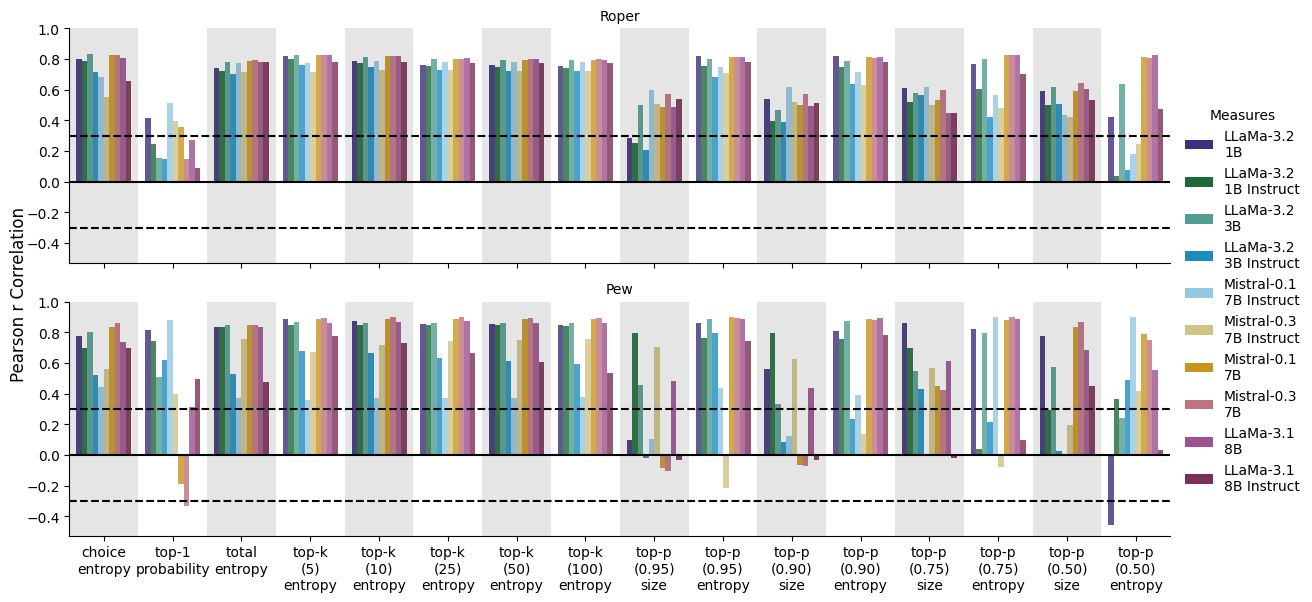

In [28]:
cp = sns.color_palette([
        '#332288',
        '#117733',
        '#44AA99',
        '#0097DE',
        '#88CCEE',
        '#DDCC77',
        '#E69F00',
        '#CC6677',
        '#AA4499',
        '#882255',
    ])
plot_align_corr('all', cp, 'pearson', 'raw', True)

## Calibration

In [ ]:
mmlu_proc_df.columns

Index(['Subject', 'Questions', 'A', 'B', 'C', 'D', 'Answers', 'model output',
       'choice-probs', 'choice-ent', 'top-1-abs', 'total-ent', 'top-k-ent-5',
       'top-k-ent-10', 'top-k-ent-25', 'top-k-ent-50', 'top-k-ent-100',
       'top-p-len-0.95', 'top-p-ent-0.95', 'top-p-len-0.9', 'top-p-ent-0.9',
       'top-p-len-0.75', 'top-p-ent-0.75', 'top-p-len-0.5', 'top-p-ent-0.5',
       'model', 'params', 'question_num', 'ref_answer', 'mod_agrees'],
      dtype='object')

In [ ]:
# Only measures where all models showed rho >= 0.5
calib_ent_measures = [
    'choice-ent',
    'total-ent',
    'top-k-ent-5',
    'top-k-ent-10',
    'top-k-ent-25',
    'top-k-ent-50',
    'top-k-ent-100',
    'top-p-ent-0.95',
    'top-p-ent-0.9',
]

In [ ]:
def minmaxNorm(df):
  return (df-df.min())/(df.max()-df.min())

def stdNorm(df):
  return (df-df.mean())/df.std()

In [ ]:
set(iroper_proc_df.columns) & set(mmlu_proc_df.columns) & set(pew_proc_df.columns)

{'Answers',
 'choice-ent',
 'choice-probs',
 'mod_agrees',
 'model',
 'model output',
 'params',
 'question_num',
 'ref_answer',
 'top-1-abs',
 'top-k-ent-10',
 'top-k-ent-100',
 'top-k-ent-25',
 'top-k-ent-5',
 'top-k-ent-50',
 'top-p-ent-0.5',
 'top-p-ent-0.75',
 'top-p-ent-0.9',
 'top-p-ent-0.95',
 'top-p-len-0.5',
 'top-p-len-0.75',
 'top-p-len-0.9',
 'top-p-len-0.95',
 'total-ent'}

C:\Users\Kyle\AppData\Local\Temp\ipykernel_38012\1579367729.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_df['measure'] = measure
C:\Users\Kyle\AppData\Local\Temp\ipykernel_38012\1579367729.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_df['dataset'] = ds_type
C:\Users\Kyle\AppData\Local\Temp\ipykernel_38012\1579367729.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-

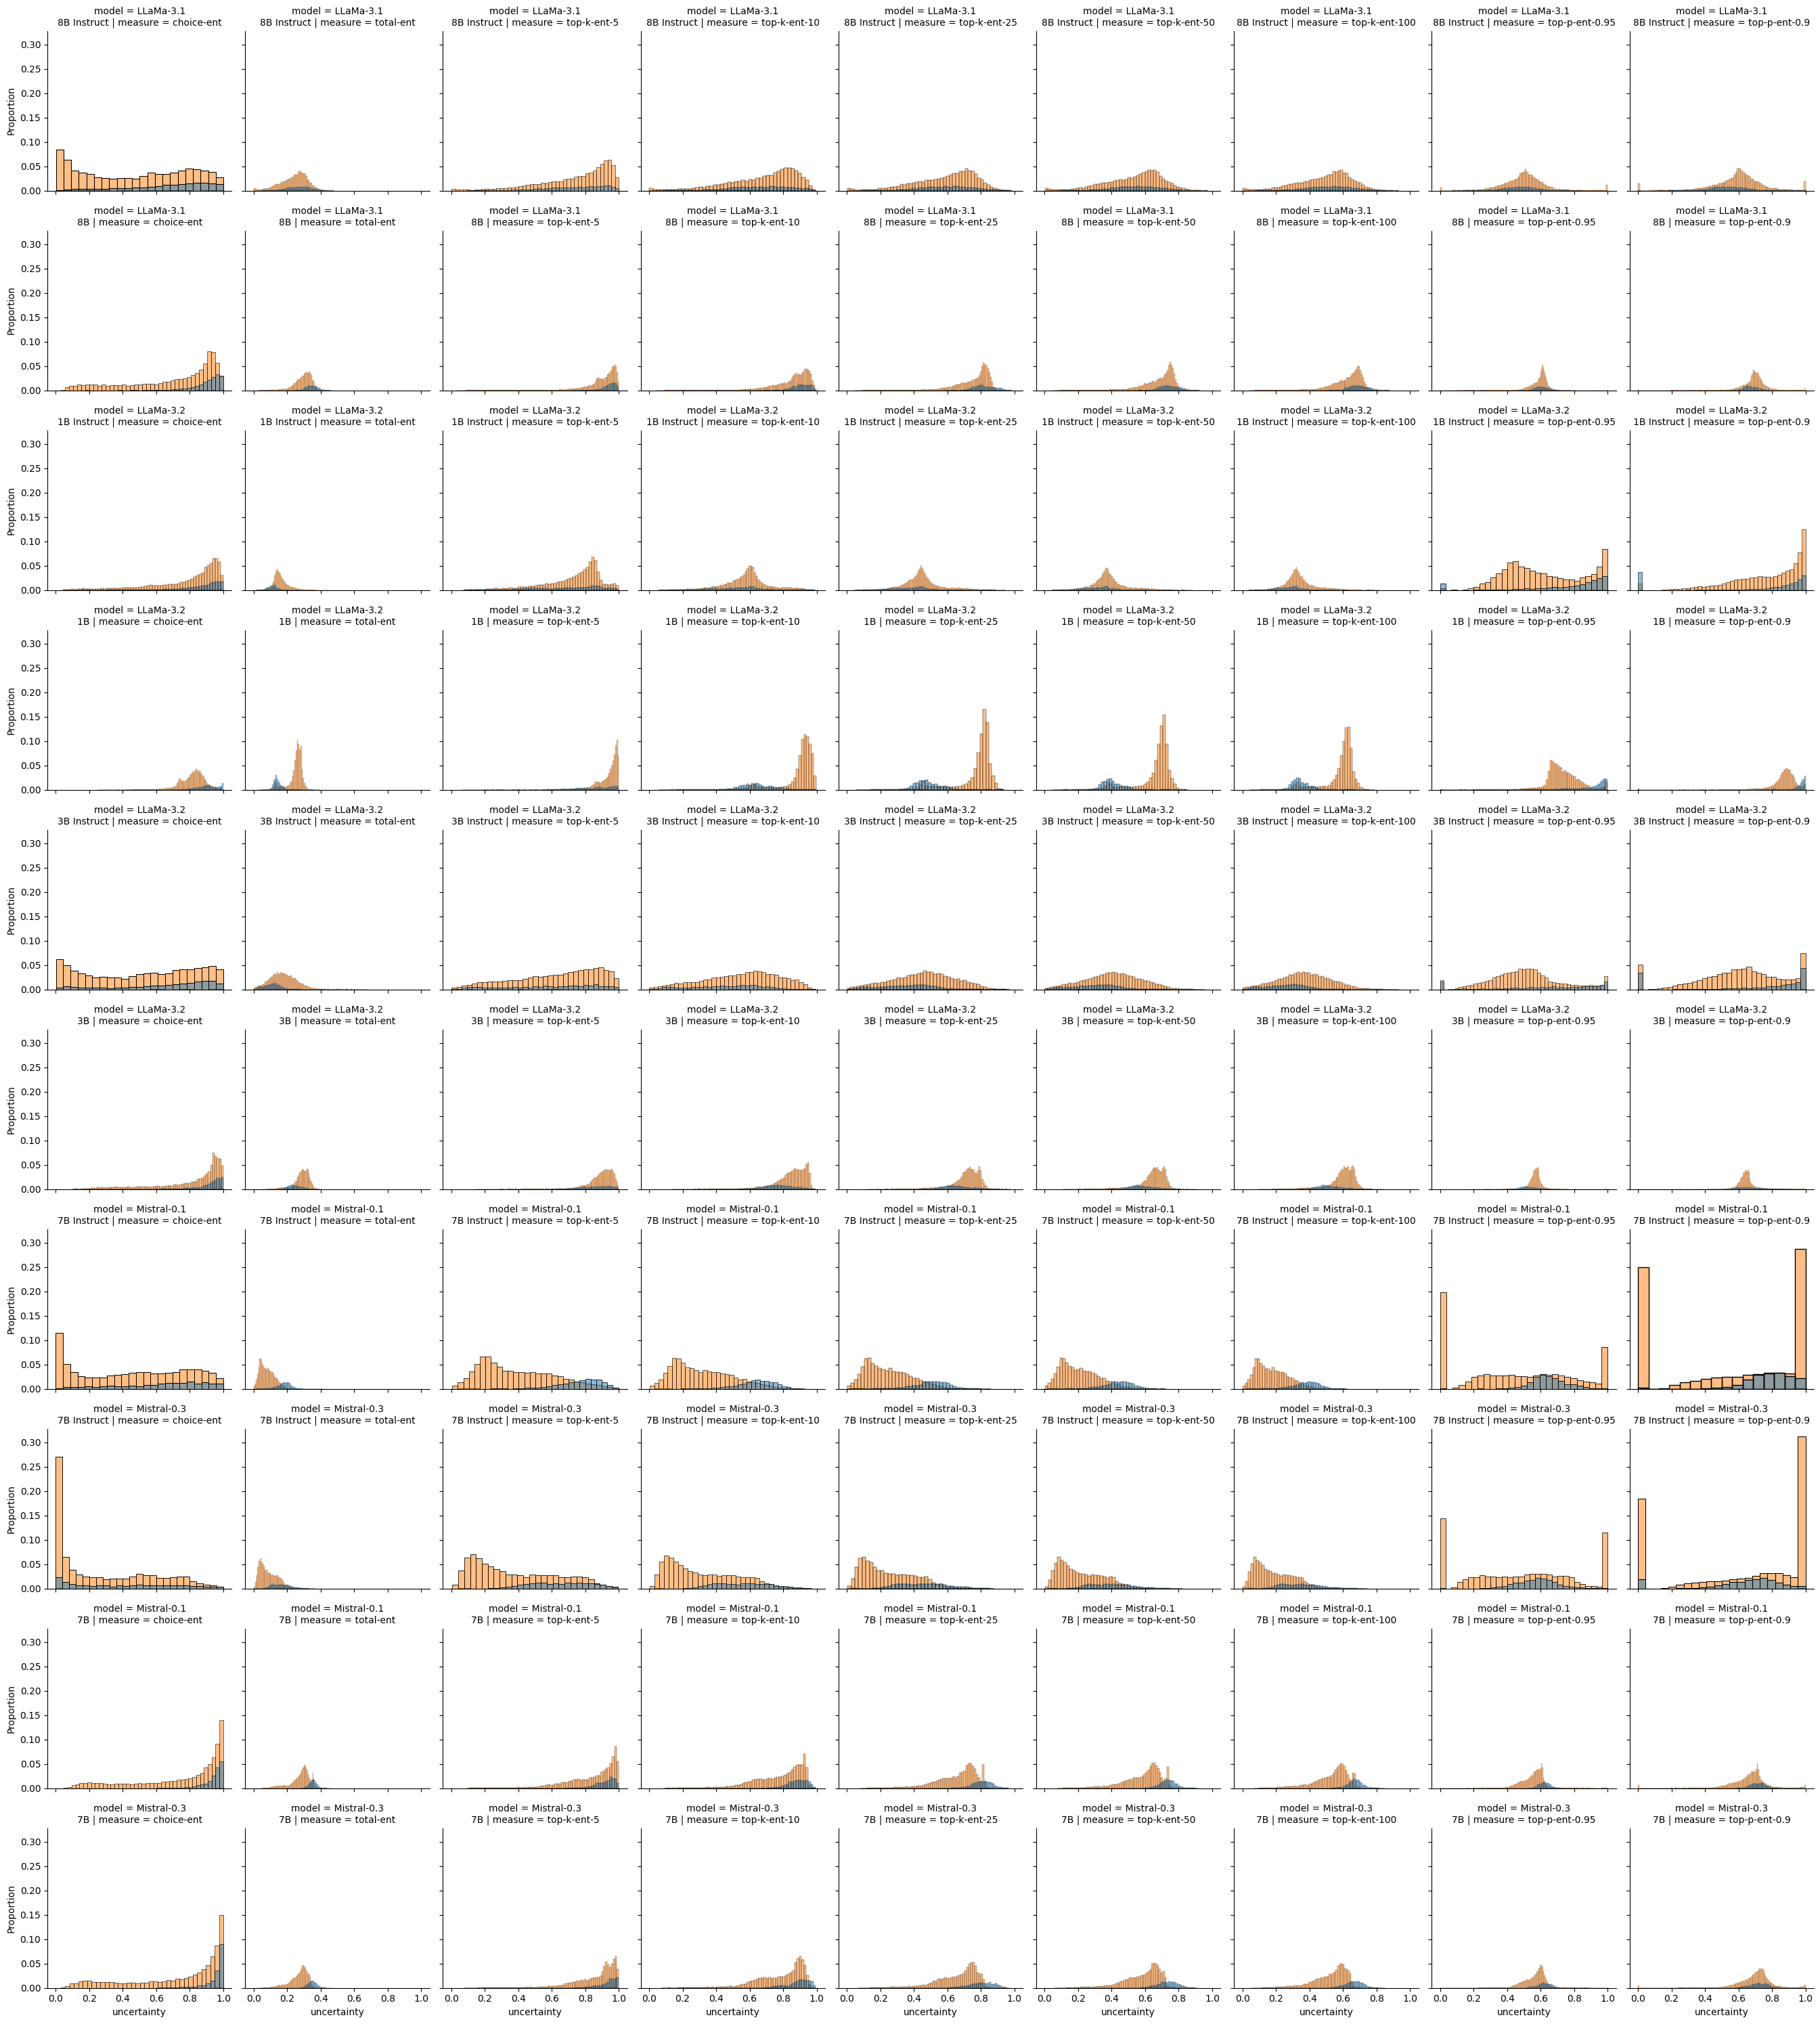

In [ ]:
def uncertainty_dists(denorm = False):
    model_map = {
        'meta-llama-llama-3.2-1b'            : 'LLaMa-3.2\n1B',
        'meta-llama-llama-3.2-1b-instruct'   : 'LLaMa-3.2\n1B Instruct',
        'meta-llama-llama-3.2-3b'            : 'LLaMa-3.2\n3B',
        'meta-llama-llama-3.2-3b-instruct'   : 'LLaMa-3.2\n3B Instruct',
        'mistralai-mistral-7b-instruct-v0.1' : 'Mistral-0.1\n7B Instruct',
        'mistralai-mistral-7b-instruct-v0.3' : 'Mistral-0.3\n7B Instruct',
        'mistralai-mistral-7b-v0.1'          : 'Mistral-0.1\n7B',
        'mistralai-mistral-7b-v0.3'          : 'Mistral-0.3\n7B',
        'meta-llama-llama-3.1-8b'            : 'LLaMa-3.1\n8B',
        'meta-llama-llama-3.1-8b-instruct'   : 'LLaMa-3.1\n8B Instruct',
    }

    measure_map = {
        'choice-ent'     : 'choice\nentropy',
        'top-1-abs'      : 'highest\ntoken\nprob.',
        'total-ent'      : 'total\nentropy',
        'top-k-ent-5'    : 'top-k\n(5)\nentropy',
        'top-k-ent-10'   : 'top-k\n(10)\nentropy',
        'top-k-ent-25'   : 'top-k\n(25)\nentropy',
        'top-k-ent-50'   : 'top-k\n(50)\nentropy',
        'top-k-ent-100'  : 'top-k\n(100)\nentropy',
        'top-p-len-0.95' : 'top-p\n(0.95)\nsize',
        'top-p-len-0.9'  : 'top-p\n(0.90)\nsize',
        'top-p-len-0.75' : 'top-p\n(0.75)\nsize',
        'top-p-len-0.5'  : 'top-p\n(0.50)\nsize',
        'top-p-ent-0.95' : 'top-p\n(0.95)\nentropy',
        'top-p-ent-0.9'  : 'top-p\n(0.90)\nentropy',
        'top-p-ent-0.75' : 'top-p\n(0.75)\nentropy',
        'top-p-ent-0.5'  : 'top-p\n(0.50)\nentropy',
    }

    irop_tmp = iroper_proc_df.copy()
    mmlu_tmp = mmlu_proc_df.copy()
    pewr_tmp = pew_proc_df.copy()

    if denorm:
        for measure in calib_ent_measures:
            irop_tmp[measure] = irop_tmp.apply(lambda x: x[measure] * np.log(len(x['Answer_Ratios'])), axis=1)
            mmlu_tmp[measure] = mmlu_tmp.apply(lambda x: x[measure] * np.log(len(x['Answer_Ratios'])), axis=1)
            pewr_tmp[measure] = pewr_tmp.apply(lambda x: x[measure] * np.log(len(x['Answer_Ratios'])), axis=1)

    focus_df = pd.DataFrame()
    for measure in calib_ent_measures:
        for ds_type, ds_df in [('iroper', irop_tmp), ('mmlu', mmlu_tmp), ('pew', pewr_tmp)]:
            tmp_df = ds_df[['model', 'params', 'mod_agrees', measure]]
            tmp_df['measure'] = measure
            tmp_df['dataset'] = ds_type
            tmp_df.rename({measure : 'uncertainty'}, inplace=True, axis=1)
            focus_df = pd.concat([focus_df, tmp_df], ignore_index=True).reset_index(drop=True)


    focus_df['model'] = focus_df['model'].map(model_map)

    g = sns.FacetGrid(focus_df, row='model', col='measure' , height=3, aspect=1, legend_out=True)
    g.map_dataframe(sns.histplot, x='uncertainty', stat='proportion', hue='dataset', common_bins=True)

    plt.show()

uncertainty_dists()

C:\Users\Kyle\AppData\Local\Temp\ipykernel_38012\942683559.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_df['measure'] = measure
C:\Users\Kyle\AppData\Local\Temp\ipykernel_38012\942683559.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_df.rename({measure : 'uncertainty'}, inplace=True, axis=1)
C:\Users\Kyle\AppData\Local\Temp\ipykernel_38012\942683559.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: h

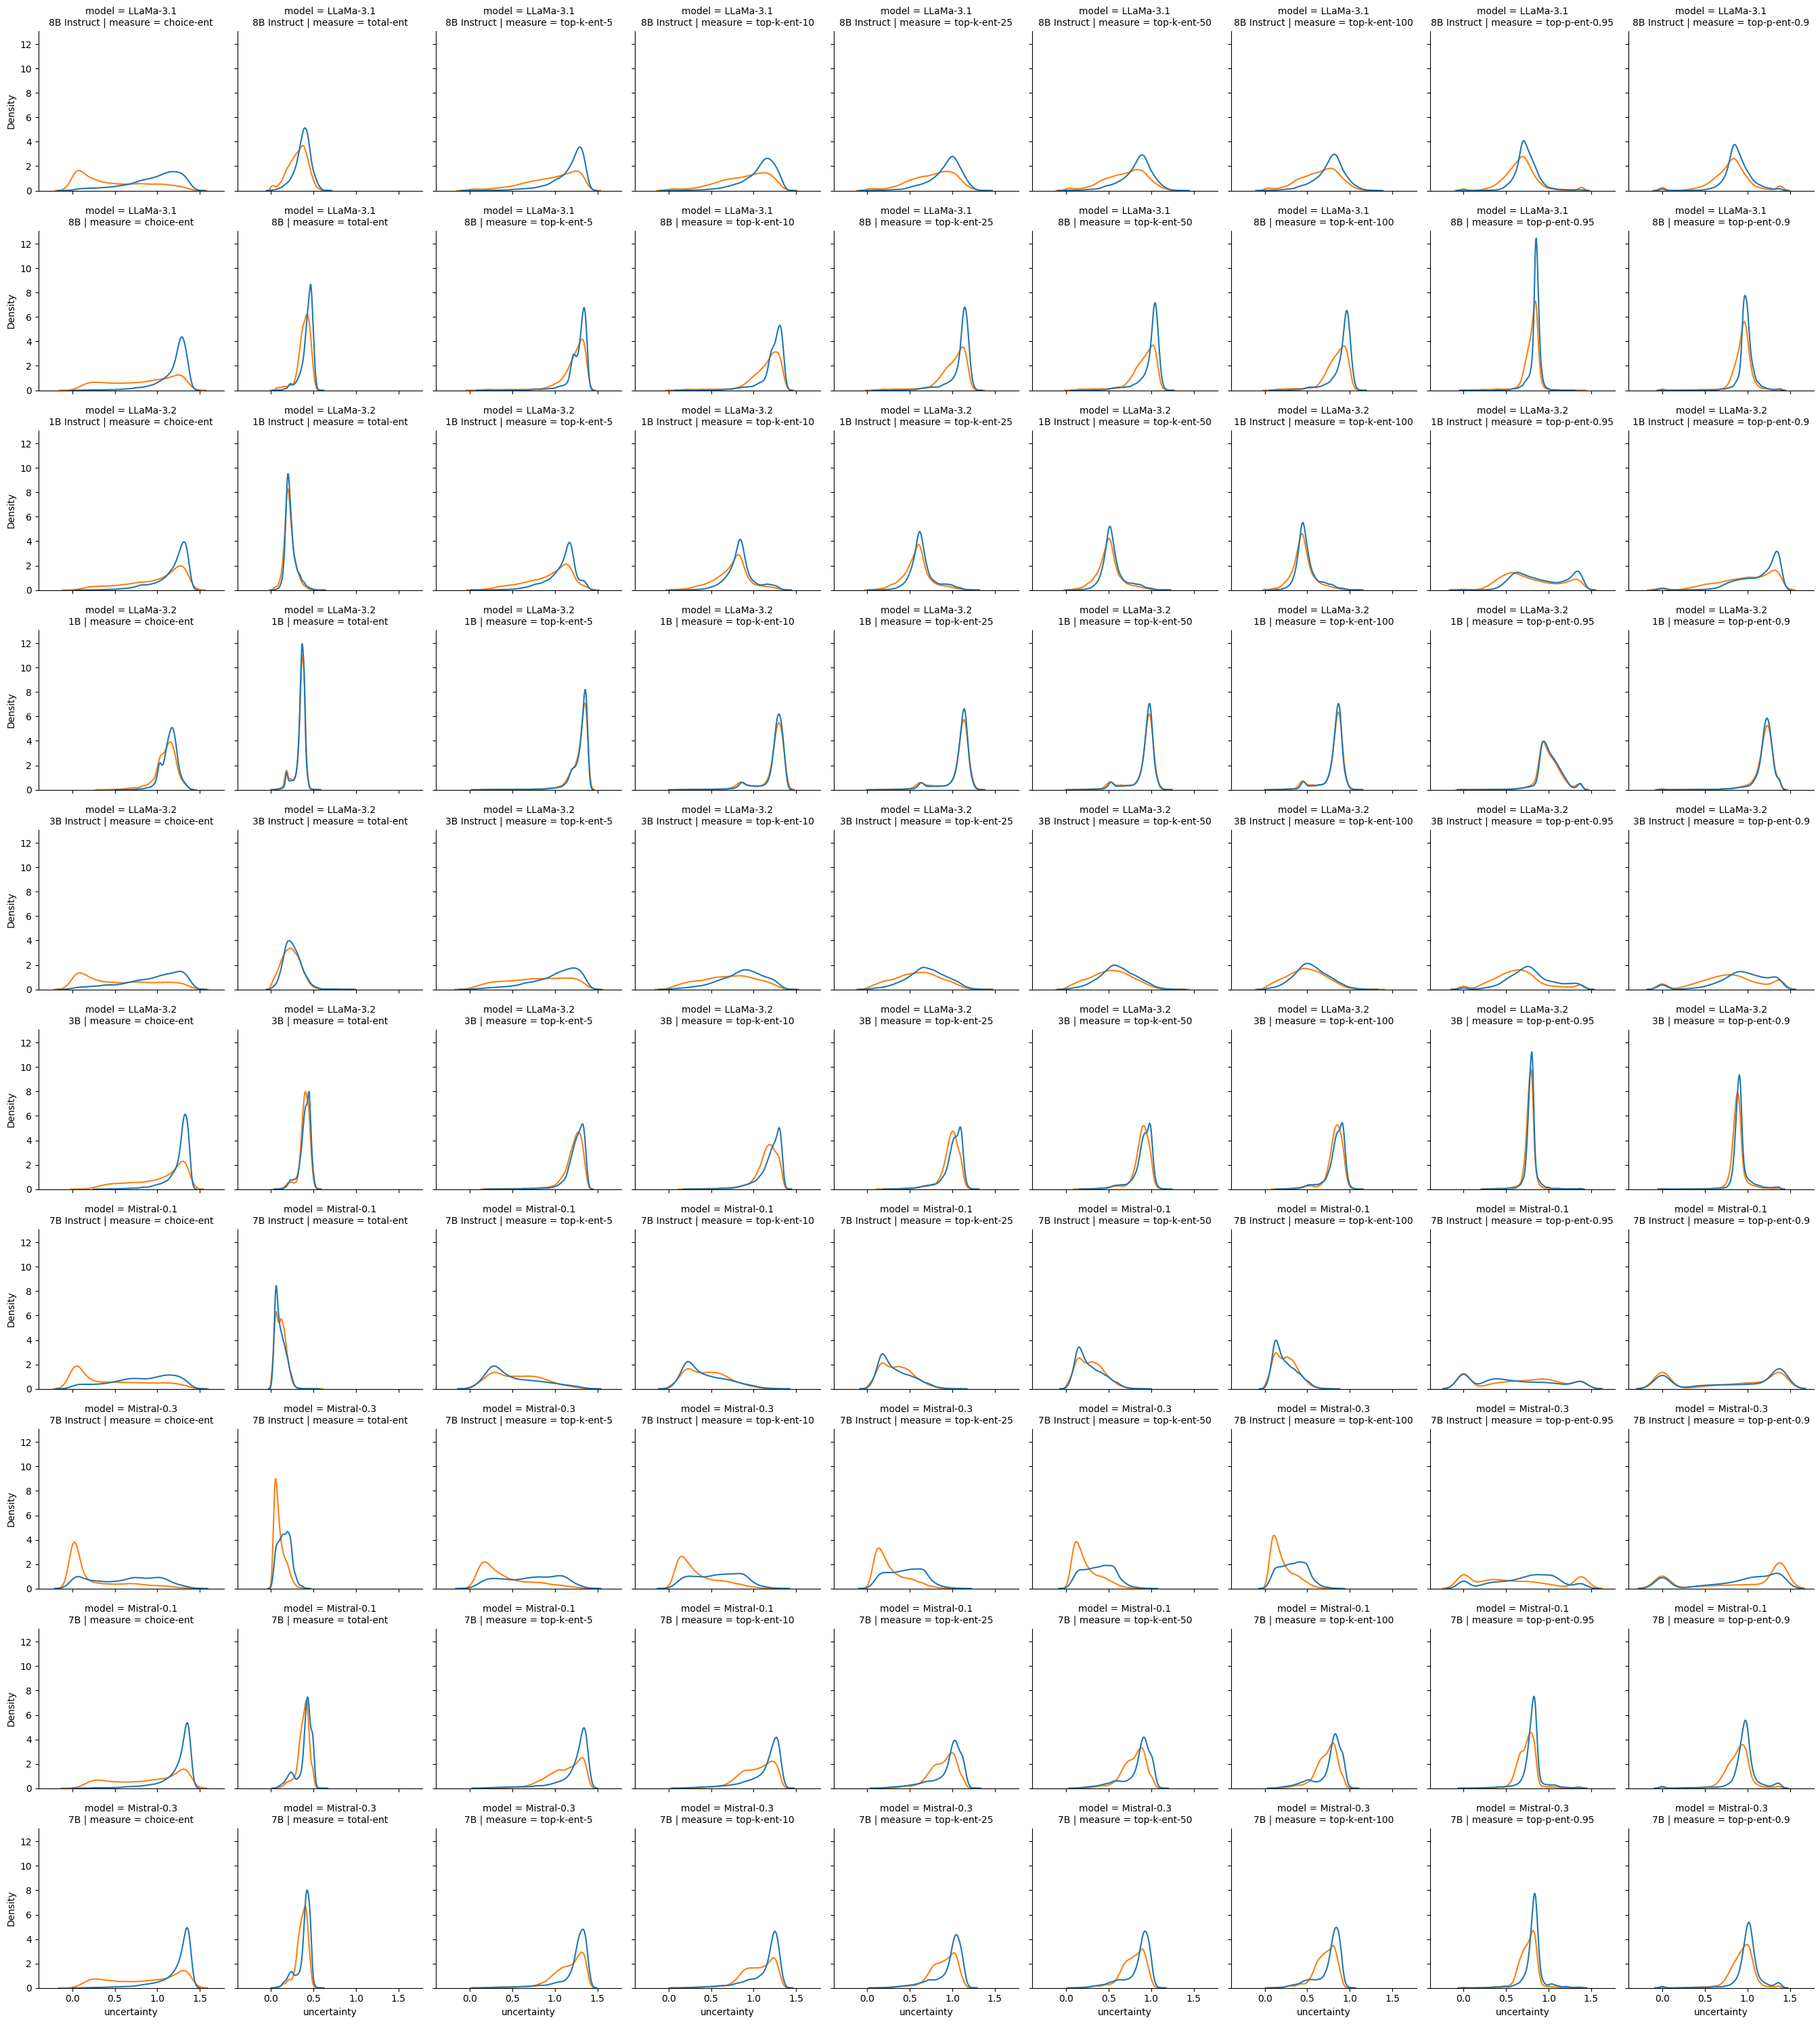

In [ ]:
def plot_calib_corr(denorm = True):
    model_map = {
        'meta-llama-llama-3.2-1b'            : 'LLaMa-3.2\n1B',
        'meta-llama-llama-3.2-1b-instruct'   : 'LLaMa-3.2\n1B Instruct',
        'meta-llama-llama-3.2-3b'            : 'LLaMa-3.2\n3B',
        'meta-llama-llama-3.2-3b-instruct'   : 'LLaMa-3.2\n3B Instruct',
        'mistralai-mistral-7b-instruct-v0.1' : 'Mistral-0.1\n7B Instruct',
        'mistralai-mistral-7b-instruct-v0.3' : 'Mistral-0.3\n7B Instruct',
        'mistralai-mistral-7b-v0.1'          : 'Mistral-0.1\n7B',
        'mistralai-mistral-7b-v0.3'          : 'Mistral-0.3\n7B',
        'meta-llama-llama-3.1-8b'            : 'LLaMa-3.1\n8B',
        'meta-llama-llama-3.1-8b-instruct'   : 'LLaMa-3.1\n8B Instruct',
    }

    measure_map = {
        'choice-ent'     : 'choice\nentropy',
        'top-1-abs'      : 'highest\ntoken\nprob.',
        'total-ent'      : 'total\nentropy',
        'top-k-ent-5'    : 'top-k\n(5)\nentropy',
        'top-k-ent-10'   : 'top-k\n(10)\nentropy',
        'top-k-ent-25'   : 'top-k\n(25)\nentropy',
        'top-k-ent-50'   : 'top-k\n(50)\nentropy',
        'top-k-ent-100'  : 'top-k\n(100)\nentropy',
        'top-p-len-0.95' : 'top-p\n(0.95)\nsize',
        'top-p-len-0.9'  : 'top-p\n(0.90)\nsize',
        'top-p-len-0.75' : 'top-p\n(0.75)\nsize',
        'top-p-len-0.5'  : 'top-p\n(0.50)\nsize',
        'top-p-ent-0.95' : 'top-p\n(0.95)\nentropy',
        'top-p-ent-0.9'  : 'top-p\n(0.90)\nentropy',
        'top-p-ent-0.75' : 'top-p\n(0.75)\nentropy',
        'top-p-ent-0.5'  : 'top-p\n(0.50)\nentropy',
    }

    mmlu_tmp = mmlu_proc_df.copy()

    if denorm:
        for measure in calib_ent_measures:
            mmlu_tmp[measure] = mmlu_tmp.apply(lambda x: x[measure] * np.log(4), axis=1)

    focus_df = pd.DataFrame()
    for measure in calib_ent_measures:
        tmp_df = mmlu_tmp[['model', 'params', 'mod_agrees', measure]]
        tmp_df['measure'] = measure
        tmp_df.rename({measure : 'uncertainty'}, inplace=True, axis=1)
        focus_df = pd.concat([focus_df, tmp_df], ignore_index=True).reset_index(drop=True)

    focus_df['model'] = focus_df['model'].map(model_map)

    g = sns.FacetGrid(focus_df, row='model', col='measure', height=3, aspect=1, legend_out=True)
    g.map_dataframe(sns.kdeplot, x='uncertainty', common_norm=False, hue='mod_agrees')#, y='corr', hue='model', palette=cp)

    plt.show()

plot_calib_corr()

In [ ]:
tmp_df = mmlu_proc_df.copy()
for measure in calib_ent_measures:
    tmp_df[measure] = tmp_df.apply(lambda x: x[measure] * np.log(4), axis=1)
    print("Spearman correlation of correct bool with {}".format(measure), tmp_df['mod_agrees'].corr(tmp_df[measure], method = 'pearson'))

Spearman correlation of correct bool with choice-ent -0.40395644614921417
Spearman correlation of correct bool with total-ent -0.08359523014757006
Spearman correlation of correct bool with top-k-ent-5 -0.1910283921507409
Spearman correlation of correct bool with top-k-ent-10 -0.17363960896806657
Spearman correlation of correct bool with top-k-ent-25 -0.15248261566119042
Spearman correlation of correct bool with top-k-ent-50 -0.13363769568042613
Spearman correlation of correct bool with top-k-ent-100 -0.11921945390783416
Spearman correlation of correct bool with top-p-ent-0.95 -0.16451740534854079
Spearman correlation of correct bool with top-p-ent-0.9 -0.15343389008409686


In [ ]:
tmp_df = mmlu_proc_df.copy()
for measure in calib_ent_measures:
    tmp_df[measure] = tmp_df.apply(lambda x: x[measure] * np.log(4), axis=1)
    print("Spearman correlation of correct bool with {}".format(measure), tmp_df['mod_agrees'].corr(tmp_df[measure], method = 'spearman'))

Spearman correlation of correct bool with choice-ent -0.39376825485690653
Spearman correlation of correct bool with total-ent -0.084375817409547
Spearman correlation of correct bool with top-k-ent-5 -0.21868221764780607
Spearman correlation of correct bool with top-k-ent-10 -0.1921943001426495
Spearman correlation of correct bool with top-k-ent-25 -0.17018569762984473
Spearman correlation of correct bool with top-k-ent-50 -0.149332157756499
Spearman correlation of correct bool with top-k-ent-100 -0.13112878415383275
Spearman correlation of correct bool with top-p-ent-0.95 -0.2154492933194761
Spearman correlation of correct bool with top-p-ent-0.9 -0.19435610912390341


In [ ]:
tmp_df = mmlu_proc_df.copy()
for measure in calib_ent_measures:
    tmp_df[measure] = tmp_df.apply(lambda x: x[measure] * np.log(4), axis=1)
    print("Spearman correlation of correct bool with {}".format(measure), tmp_df['mod_agrees'].corr(tmp_df[measure], method = 'kendall'))

Spearman correlation of correct bool with choice-ent -0.32151159668264
Spearman correlation of correct bool with total-ent -0.06889281671519294
Spearman correlation of correct bool with top-k-ent-5 -0.17855394174719655
Spearman correlation of correct bool with top-k-ent-10 -0.15692656581854494
Spearman correlation of correct bool with top-k-ent-25 -0.13895654886454234
Spearman correlation of correct bool with top-k-ent-50 -0.12192964224296933
Spearman correlation of correct bool with top-k-ent-100 -0.10706659520299697
Spearman correlation of correct bool with top-p-ent-0.95 -0.1761393105160426
Spearman correlation of correct bool with top-p-ent-0.9 -0.15939064282073717


C:\Users\Kyle\AppData\Local\Temp\ipykernel_28288\3579302442.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space on the right for colorbar


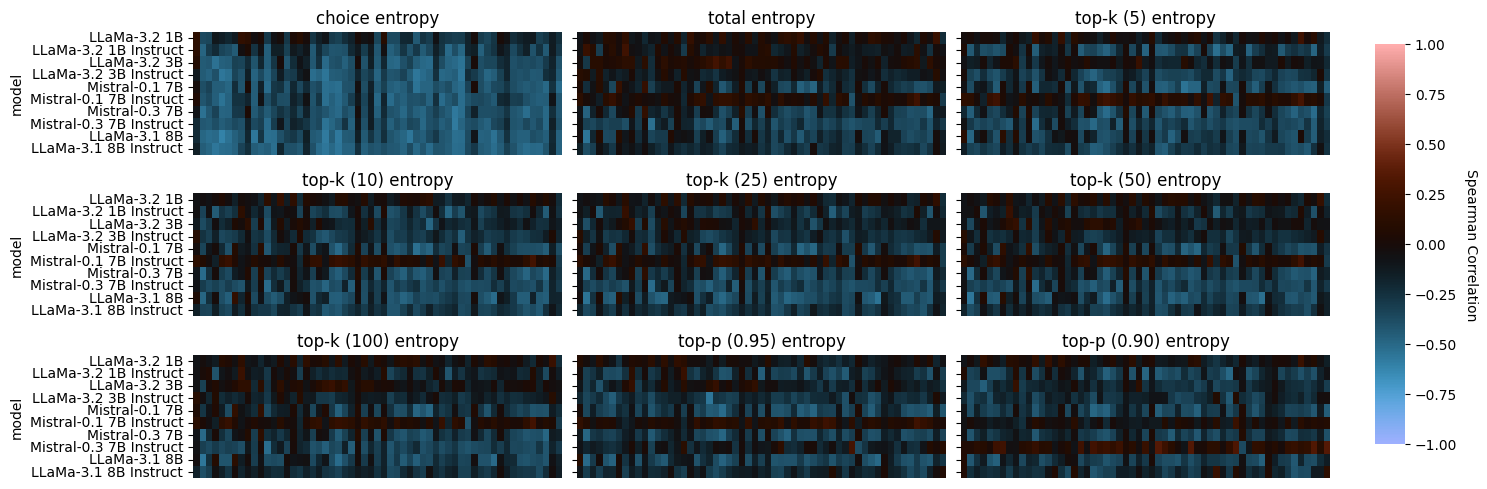

,Subject,model,correlation,params,measure
2,Abstract Algebra,LLaMa-3.2 1B,0.136700,1,choice-ent
12,Anatomy,LLaMa-3.2 1B,-0.366958,1,choice-ent
22,Astronomy,LLaMa-3.2 1B,-0.350216,1,choice-ent
32,Business Ethics,LLaMa-3.2 1B,-0.108250,1,choice-ent
42,Clinical Knowledge,LLaMa-3.2 1B,-0.148331,1,choice-ent
...,...,...,...,...,...
5081,Security Studies,LLaMa-3.1 8B Instruct,-0.362711,8,top-p-ent-0.9
5091,Sociology,LLaMa-3.1 8B Instruct,-0.371753,8,top-p-ent-0.9
5101,US Foreign Policy,LLaMa-3.1 8B Instruct,-0.118808,8,top-p-ent-0.9
5111,Virology,LLaMa-3.1 8B Instruct,-0.121117,8,top-p-ent-0.9


In [ ]:
def plot_calib_per_sub(denorm = True, focus_df = None):
    model_map = {
        'meta-llama-llama-3.2-1b'            : 'LLaMa-3.2 1B',
        'meta-llama-llama-3.2-1b-instruct'   : 'LLaMa-3.2 1B Instruct',
        'meta-llama-llama-3.2-3b'            : 'LLaMa-3.2 3B',
        'meta-llama-llama-3.2-3b-instruct'   : 'LLaMa-3.2 3B Instruct',
        'mistralai-mistral-7b-instruct-v0.1' : 'Mistral-0.1 7B Instruct',
        'mistralai-mistral-7b-instruct-v0.3' : 'Mistral-0.3 7B Instruct',
        'mistralai-mistral-7b-v0.1'          : 'Mistral-0.1 7B',
        'mistralai-mistral-7b-v0.3'          : 'Mistral-0.3 7B',
        'meta-llama-llama-3.1-8b'            : 'LLaMa-3.1 8B',
        'meta-llama-llama-3.1-8b-instruct'   : 'LLaMa-3.1 8B Instruct',
    }

    measure_map = {
        'choice-ent'     : 'choice entropy',
        'top-1-abs'      : 'highest token prob.',
        'total-ent'      : 'total entropy',
        'top-k-ent-5'    : 'top-k (5) entropy',
        'top-k-ent-10'   : 'top-k (10) entropy',
        'top-k-ent-25'   : 'top-k (25) entropy',
        'top-k-ent-50'   : 'top-k (50) entropy',
        'top-k-ent-100'  : 'top-k (100) entropy',
        'top-p-len-0.95' : 'top-p (0.95) size',
        'top-p-len-0.9'  : 'top-p (0.90) size',
        'top-p-len-0.75' : 'top-p (0.75) size',
        'top-p-len-0.5'  : 'top-p (0.50) size',
        'top-p-ent-0.95' : 'top-p (0.95) entropy',
        'top-p-ent-0.9'  : 'top-p (0.90) entropy',
        'top-p-ent-0.75' : 'top-p (0.75) entropy',
        'top-p-ent-0.5'  : 'top-p (0.50) entropy',
    }

    if focus_df is None:
        mmlu_tmp = mmlu_proc_df.copy()

        if denorm:
            for measure in calib_ent_measures:
                mmlu_tmp[measure] = mmlu_tmp.apply(lambda x: x[measure] * np.log(4), axis=1)

        focus_df = pd.DataFrame()
        subject_groups = mmlu_tmp.groupby(['Subject', 'model'], group_keys=True)


        for measure in calib_ent_measures:
            tmp_df = subject_groups.apply(lambda x: x['mod_agrees'].corr(x[measure], method='spearman'), include_groups = False).reset_index(name='correlation')

            tmp_df['params'] = tmp_df['model'].map(mmlu_tmp.drop_duplicates('model').set_index('model')['params'])

            tmp_df['model'] = tmp_df['model'].map(model_map)
            tmp_df['measure'] = measure

            focus_df = pd.concat([focus_df, tmp_df], ignore_index=True).reset_index(drop=True)

        focus_df = focus_df.sort_values(['params', 'model'], ascending=True)

    ncols = 3
    nrows = 3
    width = 5
    aspect = 3
    height = width / aspect
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(width * ncols, height * nrows))
    axes = axes.flatten()

    # Use one of the heatmaps to store the colorbar mappable
    cbar_ax = fig.add_axes([0.92, 0.1, 0.02, 0.8])  # [left, bottom, width, height]


    for i, meas in enumerate(calib_ent_measures):

        model_order = (
            focus_df[['model', 'params']]
            .drop_duplicates()
            .sort_values(['params', 'model'])['model']
        )

        ax = axes[i]
        model_df = focus_df[focus_df['measure'] == meas]
        pivoted = model_df.pivot(index='model', columns='Subject', values='correlation')
        pivoted = pivoted.reindex(model_order)

        sns.heatmap(
            pivoted,
            ax=ax,
            cmap=mpl.colormaps['berlin'],
            center=0,
            vmin=-1,
            vmax=1,
            cbar=(i == 0),          # Only show colorbar for the first subplot
            cbar_ax=(cbar_ax if i == 0 else None),  # Use custom colorbar axis
            xticklabels=False,
            yticklabels=True
        )

        ax.set_yticks(np.arange(len(pivoted.index)) + 0.5)
        ax.set_yticklabels(pivoted.index, fontsize=10, rotation=0)

        ax.set_title(f"{measure_map[meas]}")

        # Show y-tick labels only on the leftmost plots
        if i % ncols != 0:
            ax.set_yticklabels([])
            ax.set_ylabel('')
        ax.set_xlabel('')

    # Remove unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Adjust layout and add colorbar label
    plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space on the right for colorbar
    cbar_ax.set_ylabel('Spearman Correlation', rotation=270, labelpad=15)
    ax.tick_params(axis='y')

    plt.show()
    return focus_df

plot_calib_per_sub(denorm=True, focus_df=saved_df)

C:\Users\Kyle\AppData\Local\Temp\ipykernel_28288\2540734407.py:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])  # leave space on the right for colorbar


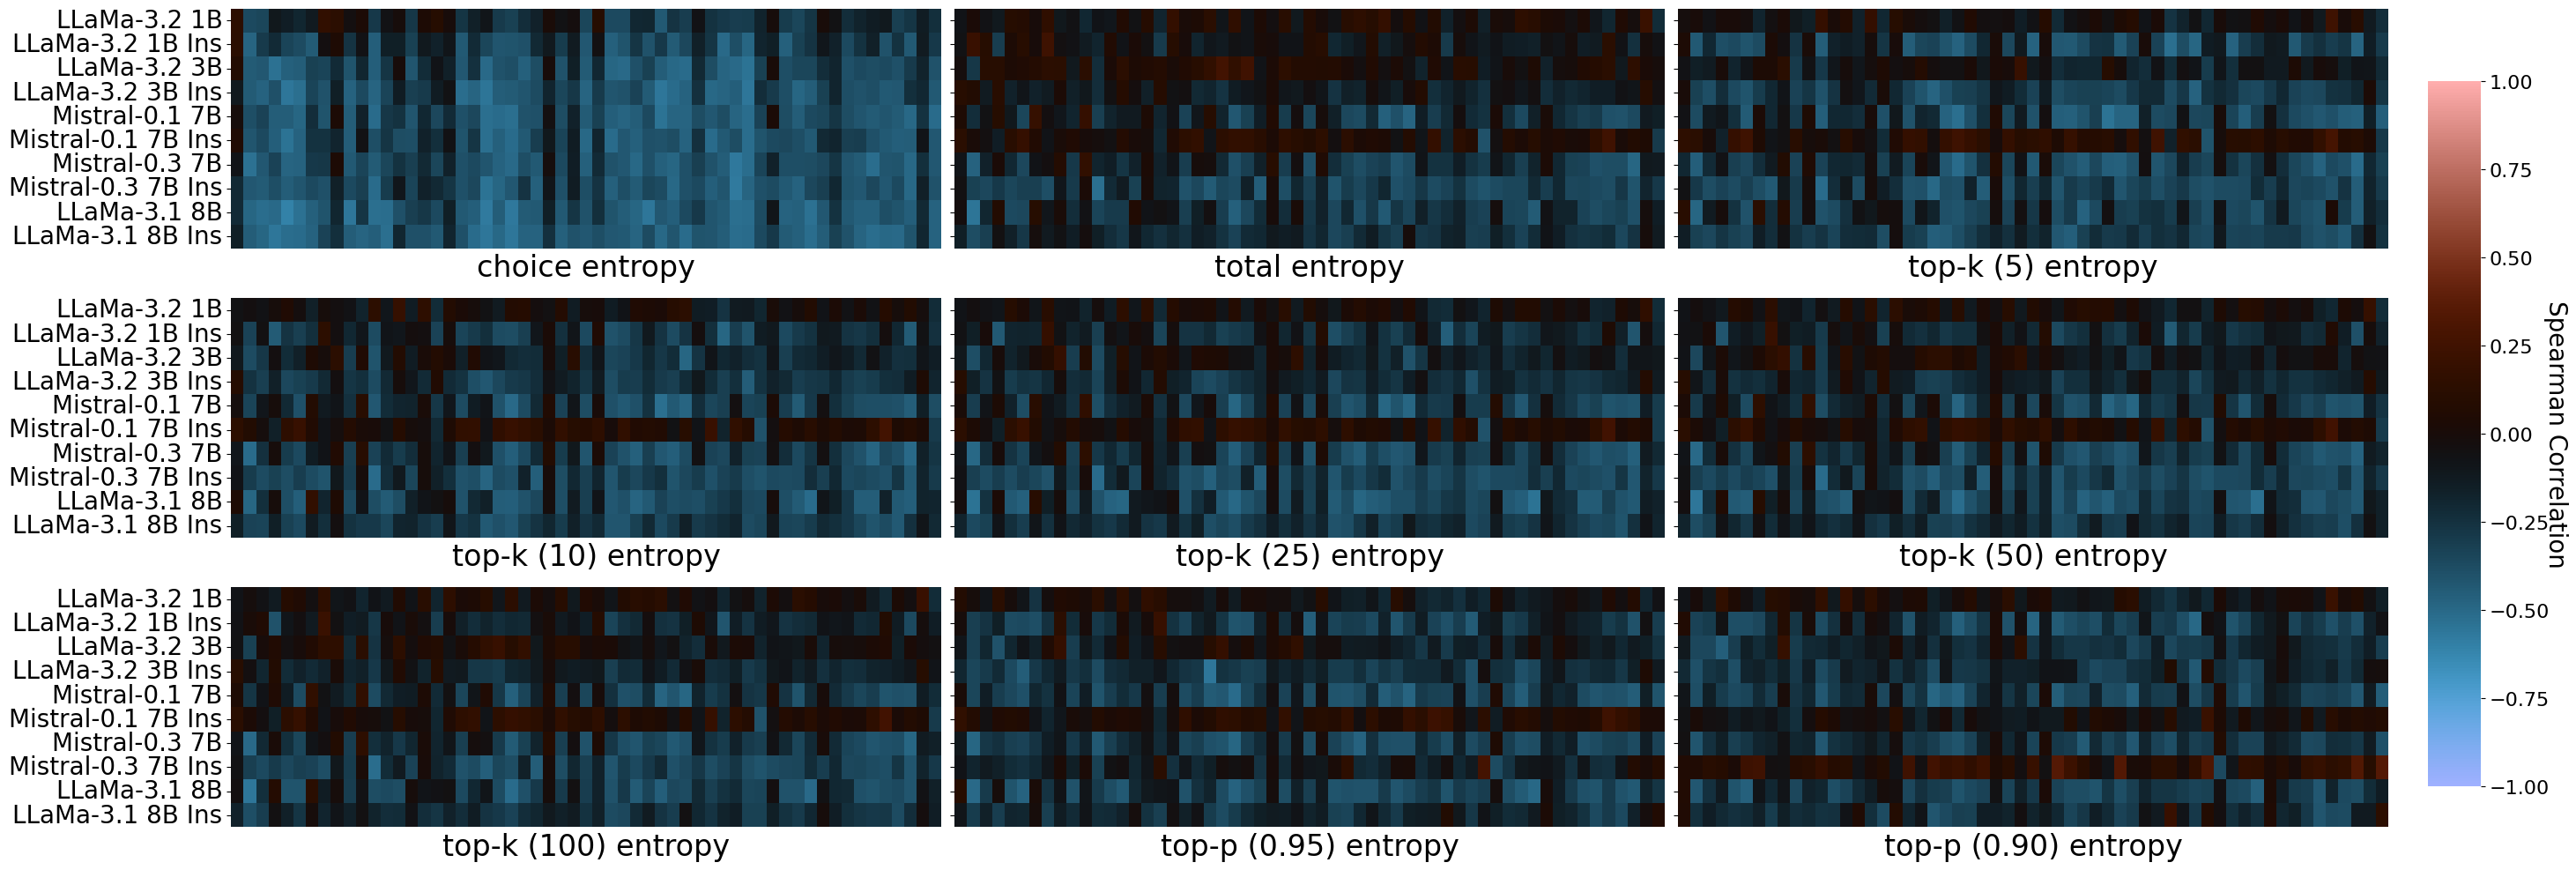

In [ ]:
def plot_calib_per_sub(denorm = True, saved_df = None):
    model_map = {
        'meta-llama-llama-3.2-1b'            : 'LLaMa-3.2 1B',
        'meta-llama-llama-3.2-1b-instruct'   : 'LLaMa-3.2 1B Instruct',
        'meta-llama-llama-3.2-3b'            : 'LLaMa-3.2 3B',
        'meta-llama-llama-3.2-3b-instruct'   : 'LLaMa-3.2 3B Instruct',
        'mistralai-mistral-7b-instruct-v0.1' : 'Mistral-0.1 7B Instruct',
        'mistralai-mistral-7b-instruct-v0.3' : 'Mistral-0.3 7B Instruct',
        'mistralai-mistral-7b-v0.1'          : 'Mistral-0.1 7B',
        'mistralai-mistral-7b-v0.3'          : 'Mistral-0.3 7B',
        'meta-llama-llama-3.1-8b'            : 'LLaMa-3.1 8B',
        'meta-llama-llama-3.1-8b-instruct'   : 'LLaMa-3.1 8B Instruct',
    }

    measure_map = {
        'choice-ent'     : 'choice entropy',
        'top-1-abs'      : 'highest token prob.',
        'total-ent'      : 'total entropy',
        'top-k-ent-5'    : 'top-k (5) entropy',
        'top-k-ent-10'   : 'top-k (10) entropy',
        'top-k-ent-25'   : 'top-k (25) entropy',
        'top-k-ent-50'   : 'top-k (50) entropy',
        'top-k-ent-100'  : 'top-k (100) entropy',
        'top-p-len-0.95' : 'top-p (0.95) size',
        'top-p-len-0.9'  : 'top-p (0.90) size',
        'top-p-len-0.75' : 'top-p (0.75) size',
        'top-p-len-0.5'  : 'top-p (0.50) size',
        'top-p-ent-0.95' : 'top-p (0.95) entropy',
        'top-p-ent-0.9'  : 'top-p (0.90) entropy',
        'top-p-ent-0.75' : 'top-p (0.75) entropy',
        'top-p-ent-0.5'  : 'top-p (0.50) entropy',
    }

    if saved_df is None:
        mmlu_tmp = mmlu_proc_df.copy()

        if denorm:
            for measure in calib_ent_measures:
                mmlu_tmp[measure] = mmlu_tmp.apply(lambda x: x[measure] * np.log(4), axis=1)

        focus_df = pd.DataFrame()
        subject_groups = mmlu_tmp.groupby(['Subject', 'model'], group_keys=True)


        for measure in calib_ent_measures:
            tmp_df = subject_groups.apply(lambda x: x['mod_agrees'].corr(x[measure], method='spearman'), include_groups = False).reset_index(name='correlation')

            tmp_df['params'] = tmp_df['model'].map(mmlu_tmp.drop_duplicates('model').set_index('model')['params'])

            tmp_df['model'] = tmp_df['model'].map(model_map)
            tmp_df['measure'] = measure

            focus_df = pd.concat([focus_df, tmp_df], ignore_index=True).reset_index(drop=True)

        focus_df = focus_df.sort_values(['params', 'model'], ascending=True)
    else:
        focus_df = saved_df.copy()


    model_map = {
        'LLaMa-3.2 1B'            : 'LLaMa-3.2 1B',
        'LLaMa-3.2 1B Instruct'   : 'LLaMa-3.2 1B Ins',
        'LLaMa-3.2 3B'            : 'LLaMa-3.2 3B',
        'LLaMa-3.2 3B Instruct'   : 'LLaMa-3.2 3B Ins',
        'Mistral-0.1 7B Instruct' : 'Mistral-0.1 7B Ins',
        'Mistral-0.3 7B Instruct' : 'Mistral-0.3 7B Ins',
        'Mistral-0.1 7B'          : 'Mistral-0.1 7B',
        'Mistral-0.3 7B'          : 'Mistral-0.3 7B',
        'LLaMa-3.1 8B'            : 'LLaMa-3.1 8B',
        'LLaMa-3.1 8B Instruct'   : 'LLaMa-3.1 8B Ins',
    }

    focus_df['model'] = focus_df['model'].map(model_map)

    ncols = 3
    nrows = 3
    width = 10
    aspect = 3
    height = width / aspect

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(width * ncols, height * nrows))

    axes = axes.flatten()

    # Use one of the heatmaps to store the colorbar mappable
    cbar_ax = fig.add_axes([0.92, 0.1, 0.02, 0.8])  # [left, bottom, width, height]


    for i, meas in enumerate(calib_ent_measures):

        model_order = (
            focus_df[['model', 'params']]
            .drop_duplicates()
            .sort_values(['params', 'model'])['model']
        )

        ax = axes[i]
        model_df = focus_df[focus_df['measure'] == meas]
        pivoted = model_df.pivot(index='model', columns='Subject', values='correlation')
        pivoted = pivoted.reindex(model_order)

        h = sns.heatmap(
            pivoted,
            ax=ax,
            cmap=mpl.colormaps['berlin'],
            center=0,
            vmin=-1,
            vmax=1,
            cbar=(i == 0),          # Only show colorbar for the first subplot
            cbar_ax=(cbar_ax if i == 0 else None),  # Use custom colorbar axis
            xticklabels=False,
            yticklabels=True
        )
        if i == 0:
            h.collections[0].colorbar.ax.tick_params(labelsize=16)

        ax.set_yticks(np.arange(len(pivoted.index)) + 0.5)
        ax.set_yticklabels(pivoted.index, fontsize=10, rotation=0)

        ax.set_title('')

        # Show y-tick labels only on the leftmost plots
        if i % ncols != 0:
            ax.set_yticklabels([])
            ax.set_ylabel('')
        ax.set_xlabel(f"{measure_map[meas]}", fontsize=24)
        ax.set_ylabel('')
        ax.tick_params(axis='y', labelsize=20)

    # Remove unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Adjust layout and add colorbar label
    plt.tight_layout(rect=[0, 0, 0.91, 1])  # leave space on the right for colorbar
    cbar_ax.set_ylabel('Spearman Correlation', rotation=270, labelpad=15, fontsize=20)

    plt.show()
    return focus_df

_ = plot_calib_per_sub(denorm=True, saved_df=saved_df)

In [ ]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm

C:\Users\Kyle\AppData\Local\Temp\ipykernel_28288\3105386496.py:95: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('berlin')
C:\Users\Kyle\AppData\Local\Temp\ipykernel_28288\3105386496.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(meas_df,
C:\Users\Kyle\AppData\Local\Temp\ipykernel_28288\3105386496.py:95: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('berlin')
C:\Users\Kyle\AppData\Local\Temp\ipykernel_28288\3105386496.py:102: FutureWarning: 

P

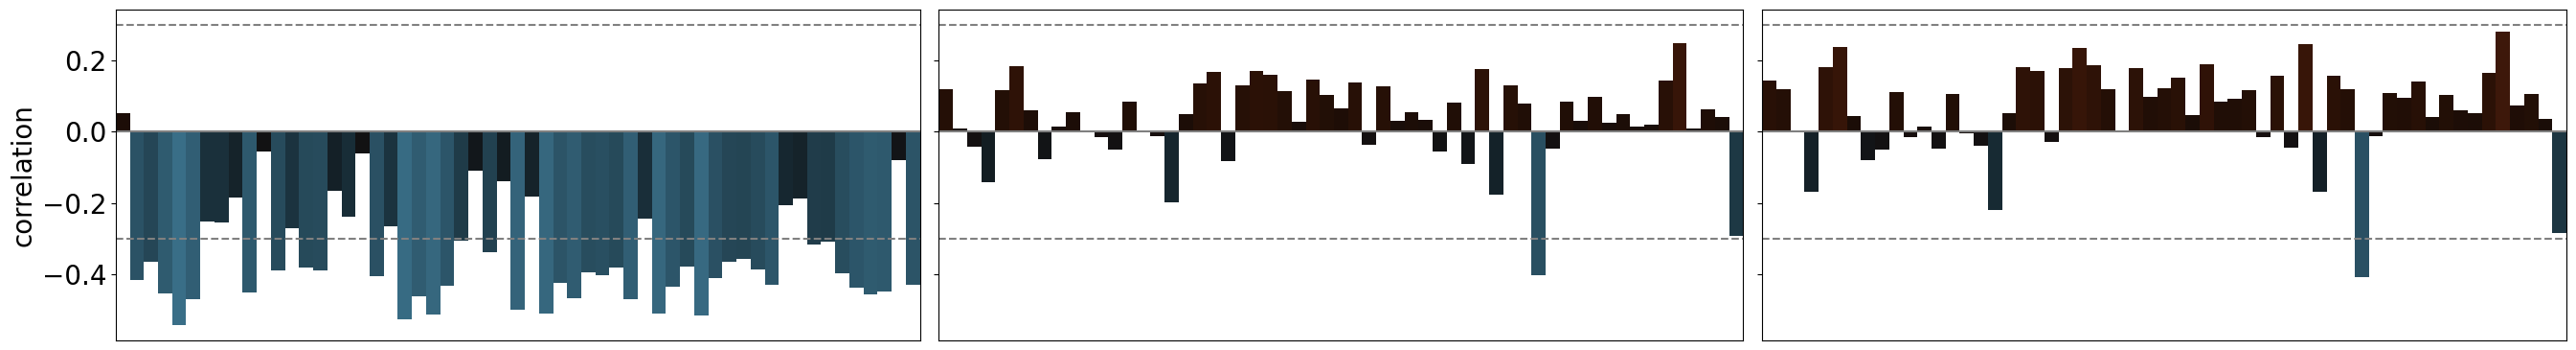

In [ ]:
def plot_calib_per_sub_bar(denorm = True, focus_df = None):
    model_map = {
        'meta-llama-llama-3.2-1b'            : 'LLaMa-3.2 1B',
        'meta-llama-llama-3.2-1b-instruct'   : 'LLaMa-3.2 1B Instruct',
        'meta-llama-llama-3.2-3b'            : 'LLaMa-3.2 3B',
        'meta-llama-llama-3.2-3b-instruct'   : 'LLaMa-3.2 3B Instruct',
        'mistralai-mistral-7b-instruct-v0.1' : 'Mistral-0.1 7B Instruct',
        'mistralai-mistral-7b-instruct-v0.3' : 'Mistral-0.3 7B Instruct',
        'mistralai-mistral-7b-v0.1'          : 'Mistral-0.1 7B',
        'mistralai-mistral-7b-v0.3'          : 'Mistral-0.3 7B',
        'meta-llama-llama-3.1-8b'            : 'LLaMa-3.1 8B',
        'meta-llama-llama-3.1-8b-instruct'   : 'LLaMa-3.1 8B Instruct',
    }

    measure_map = {
        'choice-ent'     : 'choice entropy',
        'top-1-abs'      : 'highest token prob.',
        'total-ent'      : 'total entropy',
        'top-k-ent-5'    : 'top-k (5) entropy',
        'top-k-ent-10'   : 'top-k (10) entropy',
        'top-k-ent-25'   : 'top-k (25) entropy',
        'top-k-ent-50'   : 'top-k (50) entropy',
        'top-k-ent-100'  : 'top-k (100) entropy',
        'top-p-len-0.95' : 'top-p (0.95) size',
        'top-p-len-0.9'  : 'top-p (0.90) size',
        'top-p-len-0.75' : 'top-p (0.75) size',
        'top-p-len-0.5'  : 'top-p (0.50) size',
        'top-p-ent-0.95' : 'top-p (0.95) entropy',
        'top-p-ent-0.9'  : 'top-p (0.90) entropy',
        'top-p-ent-0.75' : 'top-p (0.75) entropy',
        'top-p-ent-0.5'  : 'top-p (0.50) entropy',
    }

    if focus_df is None:
        mmlu_tmp = mmlu_proc_df.copy()

        if denorm:
            for measure in calib_ent_measures:
                mmlu_tmp[measure] = mmlu_tmp.apply(lambda x: x[measure] * np.log(4), axis=1)

        focus_df = pd.DataFrame()
        subject_groups = mmlu_tmp.groupby(['Subject', 'model'], group_keys=True)


        for measure in calib_ent_measures:
            tmp_df = subject_groups.apply(lambda x: x['mod_agrees'].corr(x[measure], method='spearman'), include_groups = False).reset_index(name='correlation')

            tmp_df['params'] = tmp_df['model'].map(mmlu_tmp.drop_duplicates('model').set_index('model')['params'])

            tmp_df['model'] = tmp_df['model'].map(model_map)
            tmp_df['measure'] = measure

            focus_df = pd.concat([focus_df, tmp_df], ignore_index=True).reset_index(drop=True)

        focus_df = focus_df.sort_values(['params', 'model'], ascending=True)

    ncols = 3
    nrows = 3
    width = 10
    aspect = 8
    height = width / aspect

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(width * ncols, height * nrows), sharey=True)

    axes = axes.flatten()

    tmp_mods = ['LLaMa-3.2 1B',
                'LLaMa-3.2 1B Instruct',
                'LLaMa-3.2 3B',
                'LLaMa-3.2 3B Instruct',
                'Mistral-0.1 7B Instruct',
                'Mistral-0.3 7B Instruct',
                'Mistral-0.1 7B',
                'Mistral-0.3 7B',
                'LLaMa-3.1 8B',
                'LLaMa-3.1 8B Instruct']

    model_df = focus_df[focus_df['model'] == tmp_mods[4]]

    for i, meas in enumerate(calib_ent_measures[:3]):
        ax = axes[i]
        meas_df = model_df[model_df['measure'] == meas]

        vmin, vmax = -1, 1

        # Normalize the values
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cmap = cm.get_cmap('berlin')

        subject_to_color = {
            subject: cmap(norm(corr))
            for subject, corr in zip(meas_df['Subject'], meas_df['correlation'])
        }

        sns.barplot(meas_df,
                    x='Subject',
                    y='correlation',
                    ax=ax,
                    legend=False,
                    palette=subject_to_color,
                    width=1,
                    )

        ax.axhline(y=0.3, linestyle='--', color='gray')
        ax.axhline(y=-0.3, linestyle='--', color='gray')
        ax.axhline(y=0, linestyle='-', color='gray')

        ax.set_xticks([])           
        ax.set_xticklabels([])
        ax.tick_params(axis='x', which='both', bottom=False, top=False)

        ax.set_xlabel('')
        ax.set_xticklabels([])
        ax.set_xticks = False
        ax.tick_params(axis='y', labelsize=20)
        ax.set_ylabel('correlation', fontsize=20)

    plt.tight_layout(rect=[0, 0, 0.9, 1]) 

    plt.show()
    return focus_df

_ = plot_calib_per_sub_bar(denorm=True, focus_df=saved_df)

C:\Users\Kyle\AppData\Local\Temp\ipykernel_28288\356463540.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space on the right for colorbar


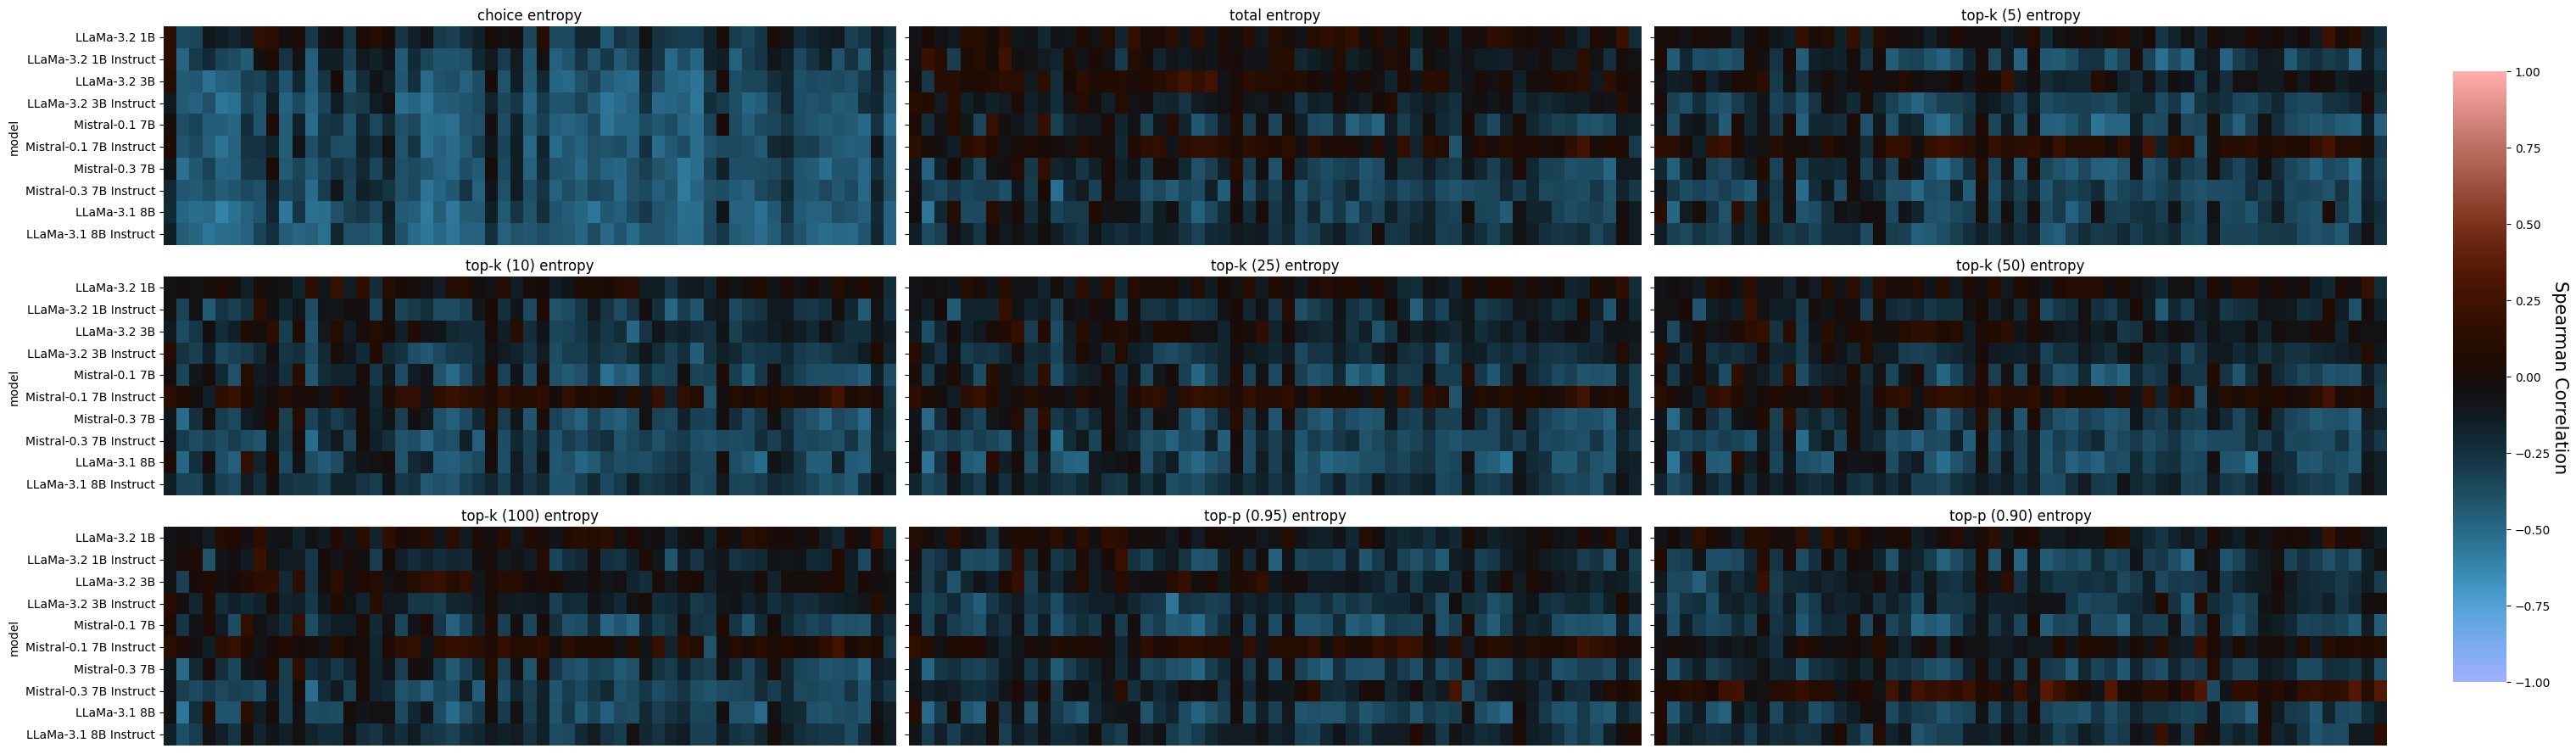

In [ ]:
saved_df = plot_calib_per_sub(denorm=True)

In [ ]:
def bin_df(df, measure, norm_vs_std, norm_split=0.5, random_assign=False):

    models_dfs = [df[df['model']==model].copy().reset_index(drop=True) for model in df['model'].unique()]

    return_df = pd.DataFrame(columns=['model', 'params', 'bin',
                                      'A-mod', 'B-mod', 'C-mod', 'D-mod',
                                      'A-cor', 'B-cor', 'C-cor', 'D-cor',
                                      'A-act', 'B-act', 'C-act', 'D-act' ])

    for mdf in models_dfs:
        if random_assign:
            mdf['bin'] = mdf['model'].apply(lambda _: random.choice(['high', 'low']))
        elif norm_vs_std == 'norm': #normalize
            mdf['norm-lin'] = (mdf[measure] - mdf[measure].min()) / (mdf[measure].max() - mdf[measure].min())
            if not(0 <= norm_split <= 1):
                raise ValueError('norm_split must be between 0 and 1')
            else:
                mdf['bin'] = np.where(mdf['norm-lin'] > norm_split, 'high', 'low')
        elif norm_vs_std == 'std': #standardize
            mdf['norm-lin'] = (mdf[measure] - mdf[measure].mean()) / mdf[measure].std()
            mdf['bin'] = np.where(mdf['norm-lin'] > 0, 'high', 'low')
            mdf.loc[mdf['norm-lin'] == 0, 'bin'] = np.random.choice(['high', 'low'], size=(mdf['norm-lin'] == 0).sum())
        else:
            raise ValueError('norm_vs_std must be either "norm" or "std"')

    dists = pd.DataFrame(columns=['model', 'bin'])

    for mdf in models_dfs:
        for b in ['low', 'high']:
            counts = mdf[(mdf['bin'] == b)].groupby('model output').size().to_dict()

            ans_cs = mdf[(mdf['bin'] == b)].groupby(['model output', 'Answers']).size().to_dict()

            for key in 'ABCD':
                counts[f'{key}**'] = 0
            for k, v in mdf[(mdf['bin'] == b)].groupby('Answers').size().to_dict().items():
                counts[f'{k}**'] = v

            for key in 'ABCD':
                if key not in counts:
                    counts[key] = 0
                counts[f'{key}*'] = ans_cs.get((key, key), 0)

            new_row = pd.DataFrame({
                'model' : [mdf['model'][0]],
                'params': [mdf['params'][0]],
                'bin'   : [b],
                'A-mod' : [counts['A']],
                'B-mod' : [counts['B']],
                'C-mod' : [counts['C']],
                'D-mod' : [counts['D']],
                'A-cor' : [counts['A*']],
                'B-cor' : [counts['B*']],
                'C-cor' : [counts['C*']],
                'D-cor' : [counts['D*']],
                'A-act' : [counts['A**']],
                'B-act' : [counts['B**']],
                'C-act' : [counts['C**']],
                'D-act' : [counts['D**']]
                })
            dists = pd.concat([dists, new_row])
        dists['measure'] = measure

    return_df = pd.concat([return_df, dists], axis=0).reset_index(drop=True)

    return return_df


In [ ]:
bin_df(mmlu_proc_df, 'std')

C:\Users\Kyle\AppData\Local\Temp\ipykernel_38012\2861766899.py:66: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return_df = pd.concat([return_df, dists], axis=0).reset_index(drop=True)


,model,params,bin,A-mod,B-mod,C-mod,D-mod,A-cor,B-cor,C-cor,D-cor,A-act,B-act,C-act,D-act,measure
0,meta-llama-llama-3.1-8b-instruct,8.0,low,1776.0,1646.0,1318.0,2029.0,1492.0,1450.0,1228.0,1772.0,1689.0,1675.0,1494.0,1911.0,choice-ent
1,meta-llama-llama-3.1-8b-instruct,8.0,high,2356.0,1823.0,1167.0,1927.0,811.0,754.0,703.0,866.0,1532.0,1788.0,2087.0,1866.0,choice-ent
2,meta-llama-llama-3.1-8b,8.0,low,1750.0,1223.0,762.0,1563.0,1411.0,1116.0,731.0,1404.0,1510.0,1303.0,942.0,1543.0,choice-ent
3,meta-llama-llama-3.1-8b,8.0,high,4427.0,1252.0,917.0,2148.0,1201.0,670.0,720.0,1003.0,1711.0,2160.0,2639.0,2234.0,choice-ent
4,meta-llama-llama-3.2-1b-instruct,1.0,low,290.0,1391.0,1801.0,1432.0,247.0,856.0,1081.0,939.0,816.0,1295.0,1430.0,1373.0,choice-ent
5,meta-llama-llama-3.2-1b-instruct,1.0,high,674.0,2336.0,4157.0,1961.0,384.0,793.0,1220.0,807.0,2405.0,2168.0,2151.0,2404.0,choice-ent
6,meta-llama-llama-3.2-1b,1.0,low,6.0,2.0,6155.0,10.0,6.0,0.0,2009.0,9.0,1292.0,1370.0,2010.0,1501.0,choice-ent
7,meta-llama-llama-3.2-1b,1.0,high,46.0,62.0,7718.0,43.0,29.0,33.0,1554.0,26.0,1929.0,2093.0,1571.0,2276.0,choice-ent
8,meta-llama-llama-3.2-3b-instruct,3.0,low,1642.0,1632.0,1469.0,1802.0,1193.0,1275.0,1238.0,1493.0,1494.0,1627.0,1631.0,1793.0,choice-ent
9,meta-llama-llama-3.2-3b-instruct,3.0,high,1795.0,1907.0,1485.0,2310.0,717.0,788.0,694.0,980.0,1727.0,1836.0,1950.0,1984.0,choice-ent


In [ ]:
def kl(p, q):
    """Kullback-Leibler divergence D(P || Q) for discrete distributions
    Parameters
    ----------
    p, q : array-like, dtype=float, shape=n
    Discrete probability distributions.
    """
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    return np.sum(np.where(p != 0, p * np.log(p / q), 0))

def plot_binned_ans_dist(df, measure, norm_vs_std='norm', norm_split=0.5, true_dist=False, relent=False):
    fig, axs = plt.subplots(2,5, figsize=(25,10))

    base_df = bin_df(df, measure, norm_vs_std, norm_split)
    base_df = base_df.sort_values(['params', 'model'], ascending=True)

    ans_dists = base_df.copy().drop(columns=['A-cor','B-cor','C-cor','D-cor', 'A-act', 'B-act', 'C-act', 'D-act']).reset_index(drop=True)
    cor_dists = base_df.copy().drop(columns=['A-mod','B-mod','C-mod','D-mod', 'A-act', 'B-act', 'C-act', 'D-act']).reset_index(drop=True)

    ans_dists = ans_dists.rename(columns={
        'A-mod': 'A',
        'B-mod': 'B',
        'C-mod': 'C',
        'D-mod': 'D',
    })
    cor_dists = cor_dists.rename(columns={
        'A-cor': 'A',
        'B-cor': 'B',
        'C-cor': 'C',
        'D-cor': 'D',
    })

    cols_to_normalize = ['A', 'B', 'C', 'D']

    cor_dists[cols_to_normalize] = cor_dists[cols_to_normalize].div(ans_dists[cols_to_normalize].sum(axis=1), axis=0)
    ans_dists[cols_to_normalize] = ans_dists[cols_to_normalize].div(ans_dists[cols_to_normalize].sum(axis=1), axis=0)

    ans_dists = ans_dists.melt(id_vars=['model', 'params', 'bin', 'measure'], var_name='Answers', value_name='counts')
    cor_dists = cor_dists.melt(id_vars=['model', 'params', 'bin', 'measure'], var_name='Answers', value_name='counts')

    for i, model in tqdm(enumerate(base_df['model'].unique())):
        col = i%5
        row = i//5

        high = base_df[(base_df['model'] == model) & (base_df['bin'] == 'high')][['A-mod', 'B-mod', 'C-mod', 'D-mod']].values[0]
        low = base_df[(base_df['model'] == model) & (base_df['bin'] == 'low')][['A-mod', 'B-mod', 'C-mod', 'D-mod']].values[0]

        if true_dist:
            ref_high = base_df[(base_df['model'] == model) & (base_df['bin'] == 'high')][['A-act', 'B-act', 'C-act', 'D-act']].values[0]
            ref_low = base_df[(base_df['model'] == model) & (base_df['bin'] == 'low')][['A-act', 'B-act', 'C-act', 'D-act']].values[0]
        else:
            ref_high = [sum(high) / 4] * 4
            ref_low = [sum(low) / 4] * 4

        h_l = scipy.stats.chisquare(list(high), list(low), sum_check=False)

        h_u_k = jensenshannon(list(high), ref_high) 
        l_u_k = jensenshannon(list(low), ref_low) 

        sns.barplot(y='counts', x='Answers', hue='bin', data=ans_dists[ans_dists['model'] == model], ax=axs[row,col], fill=False)
        sns.barplot(y='counts', x='Answers', hue='bin', data=cor_dists[cor_dists['model'] == model], ax=axs[row,col])

        stats_txt = '''U vs C:
  {h_l_s}, p={h_l_p}
U vs T:
  {h_u_k}
C vs T:
  {l_u_k}'''.format(h_l_s=h_l.statistic, h_l_p=h_l.pvalue, h_u_k=h_u_k, l_u_k=l_u_k)

        axs[row,col].text(0.05, 0.75, f'high vs. low:\n  {h_l.statistic:.3}, p={h_l.pvalue:.3}\nhigh vs. U:\n  k={h_u_k}\nlow vs. U:\n  k={l_u_k}', transform=axs[row,col].transAxes)

        axs[row,col].set_title(f'{model}')

    for ax in axs.flat:
        ax.set(ylim=(0, 1))

    plt.tight_layout()
    plt.show()


C:\Users\Kyle\AppData\Local\Temp\ipykernel_38012\2861766899.py:66: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return_df = pd.concat([return_df, dists], axis=0).reset_index(drop=True)
10it [00:01,  7.95it/s]


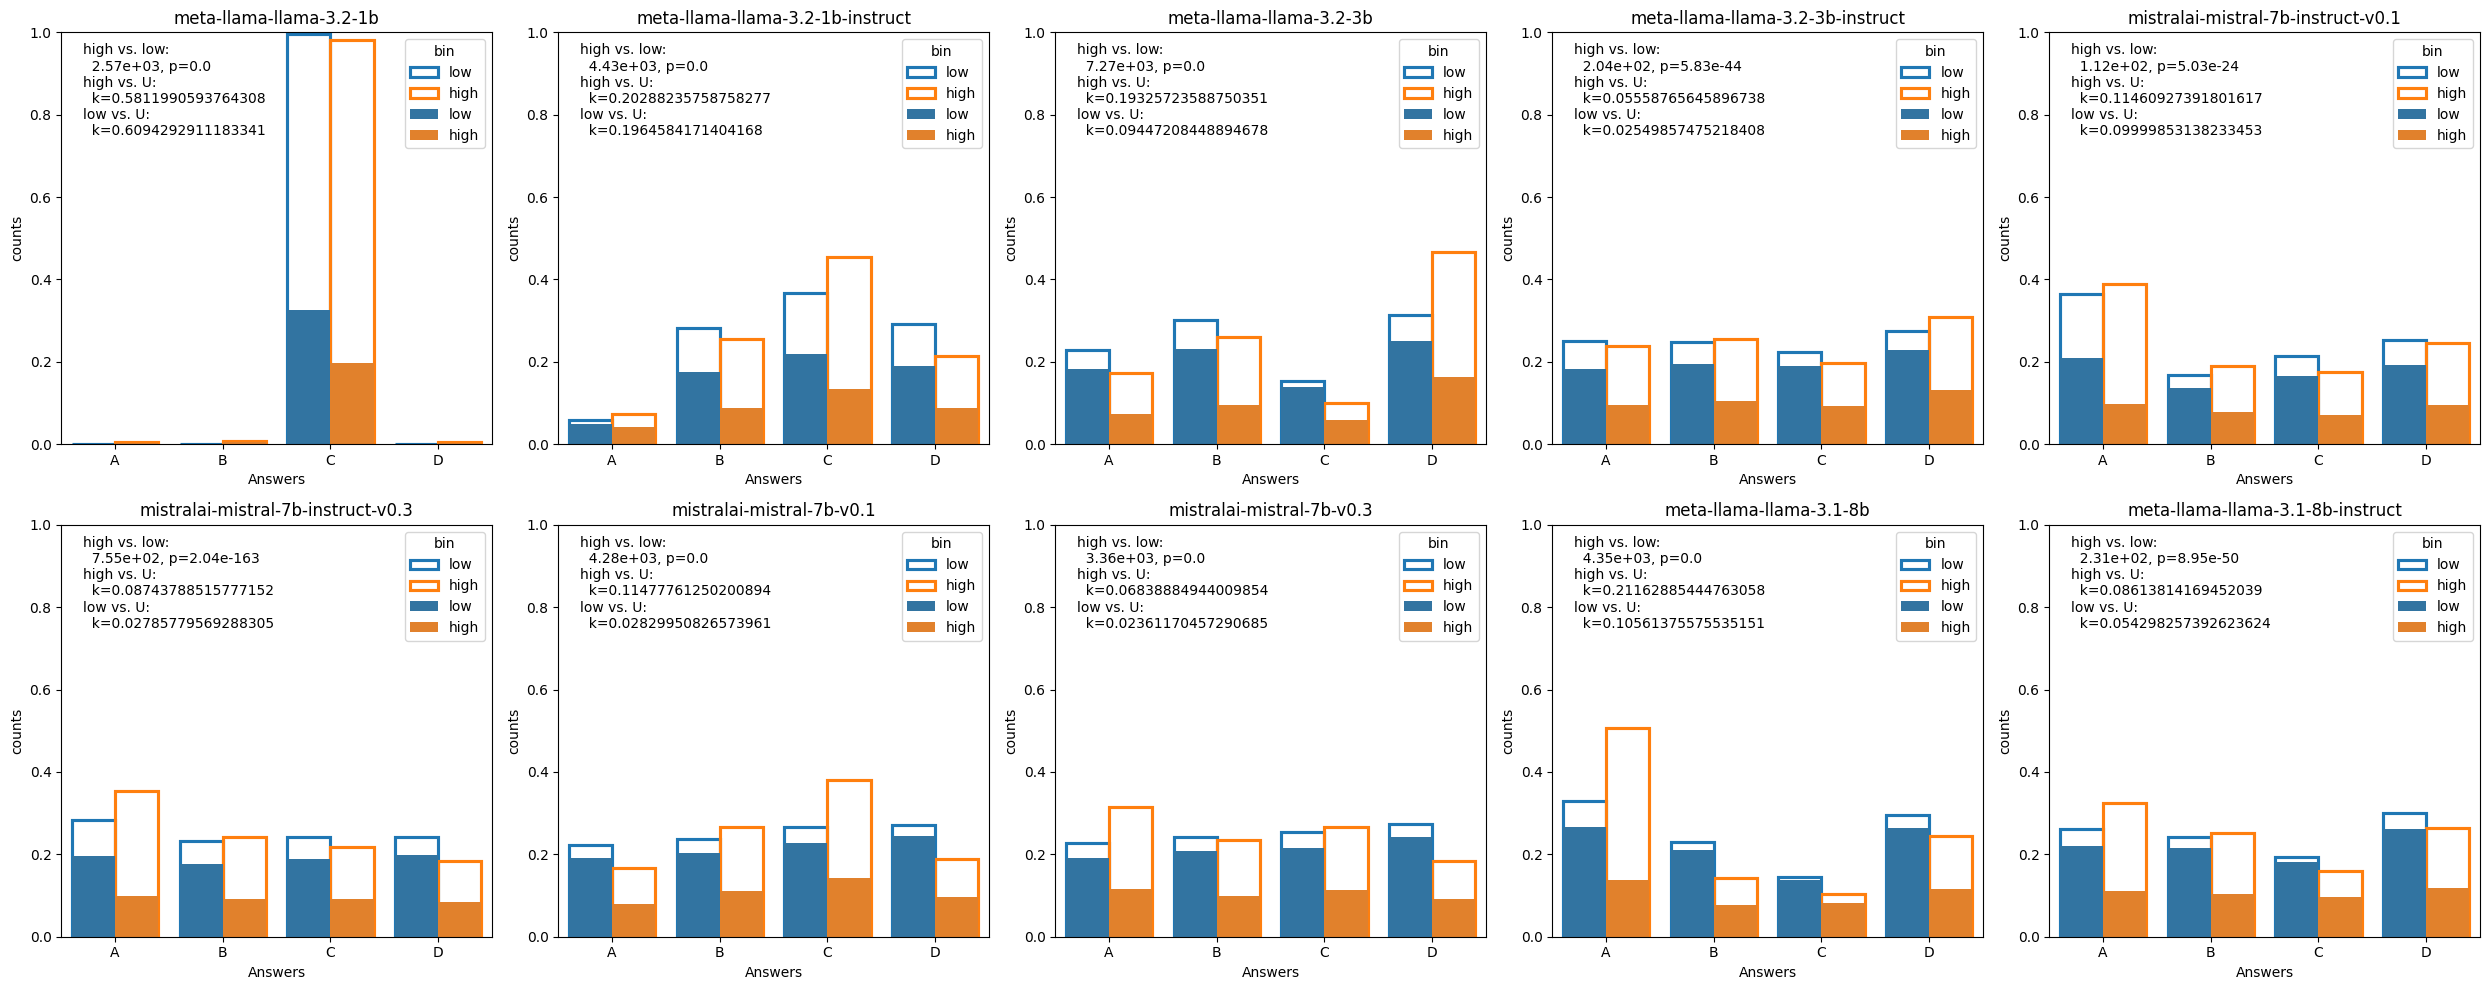

In [ ]:
plot_binned_ans_dist(mmlu_proc_df, 'choice-ent', 'std')

In [ ]:
# Bootstrapping-based test

def normalize(counts):
    counts = np.asarray(counts)
    if counts.sum() == 0:
        return counts
    else:
        return counts / counts.sum()

def norm_diff(p, q):
    return (p - q) / (p + q + 1e-10)

def js_distance(p, q):
    p = normalize(p)
    q = normalize(q)
    return jensenshannon(p, q)

def bootstrap_test(P, P_prime, Q, Q_prime, n_iterations=10000, seed=757):
    np.random.seed(seed)

    # Normalize all histograms
    P, P_prime = map(normalize, (P, P_prime))
    Q, Q_prime = map(normalize, (Q, Q_prime))

    # Compute original test statistic
    T_obs = js_distance(Q, Q_prime) - js_distance(P, P_prime)


    # Bootstrap resampling
    all_distributions = {
        'P': P, 'P_prime': P_prime,
        'Q': Q, 'Q_prime': Q_prime
    }

    def resample_distribution(dist):
        n = int(sum(dist))
        return np.random.multinomial(n, dist)

    T_bootstrap = []
    for _ in range(n_iterations):
        P_star = normalize(resample_distribution(P))
        Pp_star = normalize(resample_distribution(P_prime))
        Q_star = normalize(resample_distribution(Q))
        Qp_star = normalize(resample_distribution(Q_prime))

        t_star = js_distance(Q_star, Qp_star) - js_distance(P_star, Pp_star)
        T_bootstrap.append(t_star)

    T_bootstrap = np.array(T_bootstrap)

    # Two-sided p-value: proportion of bootstrap samples where T* ≥ T_obs
    p_value = np.mean(np.abs(T_bootstrap) >= np.abs(T_obs))

    return {
        'T_obs': T_obs,
        'p_value': p_value
    }

In [ ]:
output_df = pd.DataFrame()

for measure in calib_ent_measures:
    tmp = bin_df(mmlu_proc_df, measure, 'std')
    meas_t = []
    meas_p = []
    for model in tmp['model'].unique():
        p = tmp[(tmp['model'] == model) & (tmp['bin'] == 'high')]
        q = tmp[(tmp['model'] == model) & (tmp['bin'] == 'low')]

        p_prime = p[['A-act', 'B-act', 'C-act', 'D-act']].to_numpy().flatten()
        p       = p[['A-mod', 'B-mod', 'C-mod', 'D-mod']].to_numpy().flatten()

        q_prime = q[['A-act', 'B-act', 'C-act', 'D-act']].to_numpy().flatten()
        q       = q[['A-mod', 'B-mod', 'C-mod', 'D-mod']].to_numpy().flatten()

        test_res = bootstrap_test(q, q_prime, p, p_prime, 10000)
        meas_t.append(test_res['T_obs'])
        meas_p.append(test_res['p_value'])

    output_df[f'{measure}, T'] = meas_t
    output_df[f'{measure}, p'] = meas_p

output_df['model'] = tmp['model'].unique()
output_df

C:\Users\Kyle\AppData\Local\Temp\ipykernel_38012\3193107966.py:65: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return_df = pd.concat([return_df, dists], axis=0).reset_index(drop=True)
c:\Users\Kyle\miniconda3\envs\analysis\Lib\site-packages\scipy\spatial\distance.py:1378: RuntimeWarning: invalid value encountered in divide
  p = p / np.sum(p, axis=axis, keepdims=True)
c:\Users\Kyle\miniconda3\envs\analysis\Lib\site-packages\scipy\spatial\distance.py:1379: RuntimeWarning: invalid value encountered in divide
  q = q / np.sum(q, axis=axis, keepdims=True)
C:\Users\Kyle\AppData\Local\Temp\ipykernel_38012\3193107966.py:65: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, thi

,"choice-ent, T","choice-ent, p","total-ent, T","total-ent, p","top-k-ent-5, T","top-k-ent-5, p","top-k-ent-10, T","top-k-ent-10, p","top-k-ent-25, T","top-k-ent-25, p","top-k-ent-50, T","top-k-ent-50, p","top-k-ent-100, T","top-k-ent-100, p","top-p-ent-0.95, T","top-p-ent-0.95, p","top-p-ent-0.9, T","top-p-ent-0.9, p",model
0,0.661829,0.3800,0.556815,0.0000,0.788977,0.0000,0.689227,0.3857,0.624745,0.3785,0.594844,0.3771,0.572386,0.3792,0.401474,0.3751,0.421793,0.0000,meta-llama-llama-3.1-8b-instruct
1,0.715320,0.3734,0.419374,0.3777,0.142612,0.0000,0.436170,0.0000,0.486999,0.0000,0.470276,0.3740,0.447355,0.3755,0.501287,0.0000,0.247519,0.3773,meta-llama-llama-3.1-8b
2,0.270200,0.0000,0.044193,0.3898,0.405366,0.3935,0.382189,0.3894,0.283446,0.3858,0.207909,0.3921,0.153824,0.3934,0.290873,0.3837,0.369664,0.3876,meta-llama-llama-3.2-1b-instruct
3,0.046677,0.3996,0.028905,0.3812,0.047147,0.3842,0.059907,0.3852,0.053230,0.3873,0.045514,0.0000,0.039717,0.3791,0.013885,0.3776,0.022671,0.3842,meta-llama-llama-3.2-1b
4,0.386425,0.3724,0.240577,0.0000,0.383310,0.3915,0.351869,0.3989,0.327844,0.3912,0.311120,0.3910,0.306279,0.3906,0.391881,0.3844,0.336149,0.3841,meta-llama-llama-3.2-3b-instruct
5,0.600980,0.0000,0.135094,0.3789,0.325655,0.3875,0.453866,0.3885,0.352155,0.3819,0.250539,0.3825,0.188677,0.3816,0.257746,0.0000,0.369123,0.3777,meta-llama-llama-3.2-3b
6,0.251104,0.3815,-0.519057,0.3980,-0.560170,0.0000,-0.542949,0.4026,-0.533403,0.3991,-0.527102,0.0000,-0.525070,0.3988,-0.419549,0.3858,0.226513,0.3804,mistralai-mistral-7b-instruct-v0.1
7,0.582551,0.3789,0.547219,0.3712,0.571613,0.0000,0.554938,0.3728,0.543030,0.3702,0.545738,0.3704,0.541541,0.0000,0.454244,0.3817,0.157411,0.3687,mistralai-mistral-7b-instruct-v0.3
8,0.817775,0.3860,0.119536,0.3785,0.369372,0.3777,0.260220,0.3821,0.230103,0.3854,0.196051,0.3789,0.176362,0.0000,0.596030,0.3748,0.614535,0.0000,mistralai-mistral-7b-v0.1
9,0.849276,0.3835,0.157383,0.3814,0.218088,0.3808,0.165144,0.3751,0.157816,0.3745,0.158644,0.3746,0.156761,0.3787,0.373578,0.3886,0.293800,0.3849,mistralai-mistral-7b-v0.3


  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [01:18<00:00, 12.73it/s]


meta-llama-llama-3.1-8b-instruct


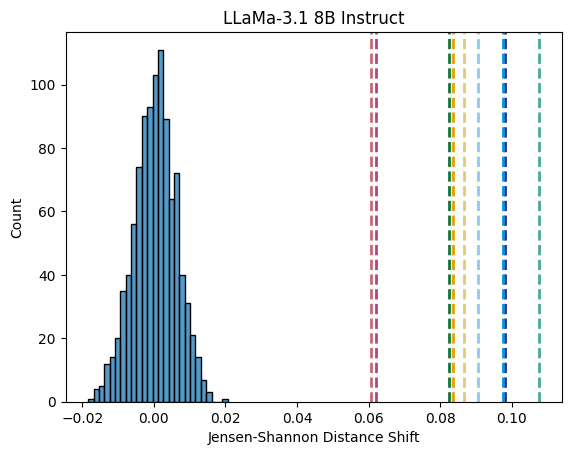

100%|██████████| 1000/1000 [01:14<00:00, 13.43it/s]


meta-llama-llama-3.1-8b


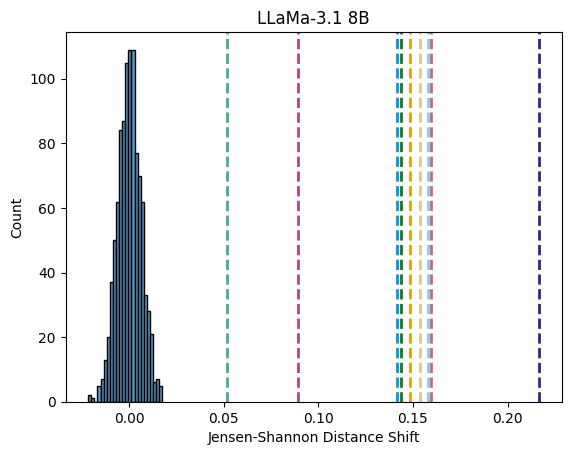

100%|██████████| 1000/1000 [01:10<00:00, 14.19it/s]


meta-llama-llama-3.2-1b-instruct


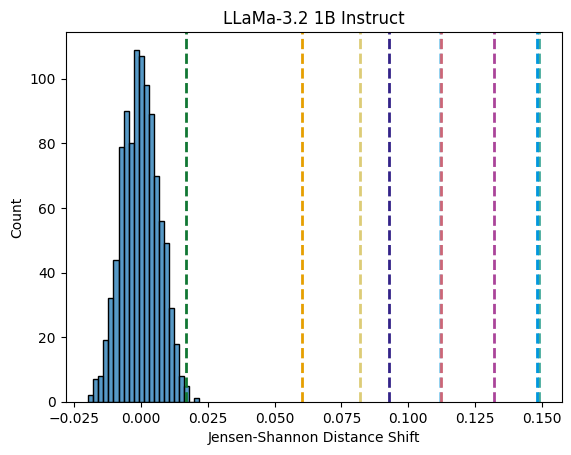

100%|██████████| 1000/1000 [01:09<00:00, 14.29it/s]


meta-llama-llama-3.2-1b


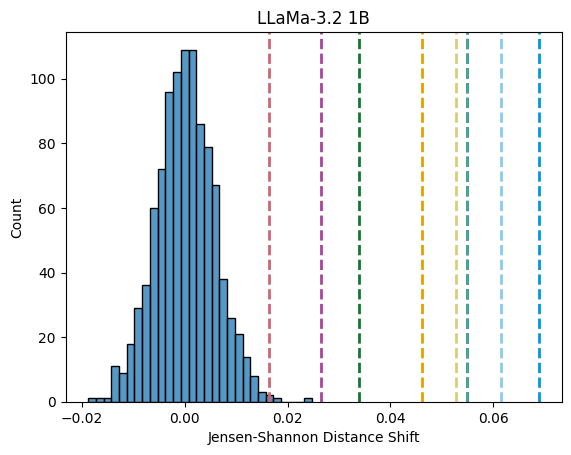

100%|██████████| 1000/1000 [01:09<00:00, 14.40it/s]


meta-llama-llama-3.2-3b-instruct


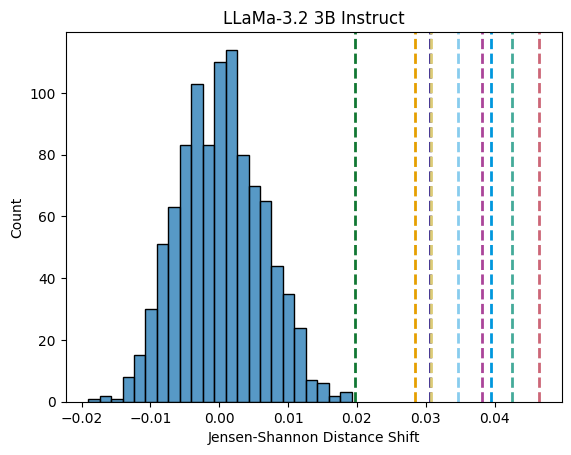

100%|██████████| 1000/1000 [01:08<00:00, 14.58it/s]


meta-llama-llama-3.2-3b


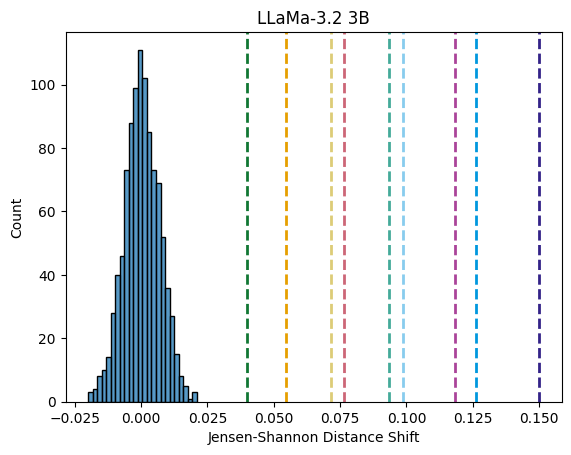

100%|██████████| 1000/1000 [01:09<00:00, 14.48it/s]


mistralai-mistral-7b-instruct-v0.1


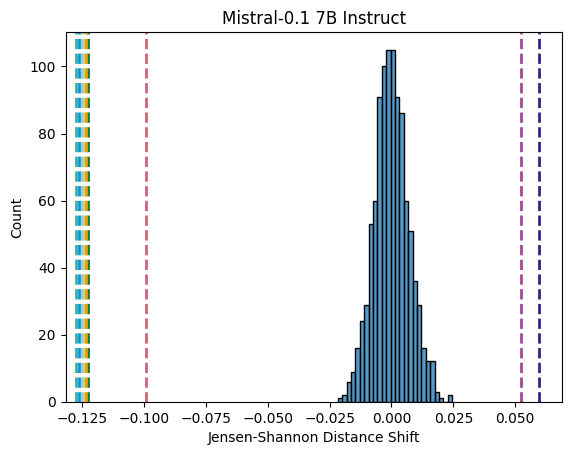

100%|██████████| 1000/1000 [01:08<00:00, 14.56it/s]


mistralai-mistral-7b-instruct-v0.3


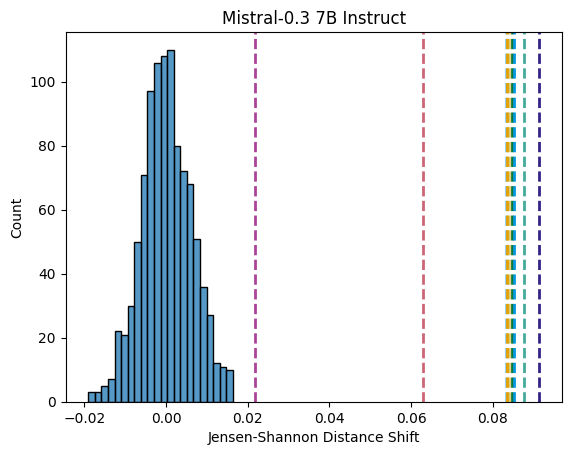

100%|██████████| 1000/1000 [01:07<00:00, 14.74it/s]


mistralai-mistral-7b-v0.1


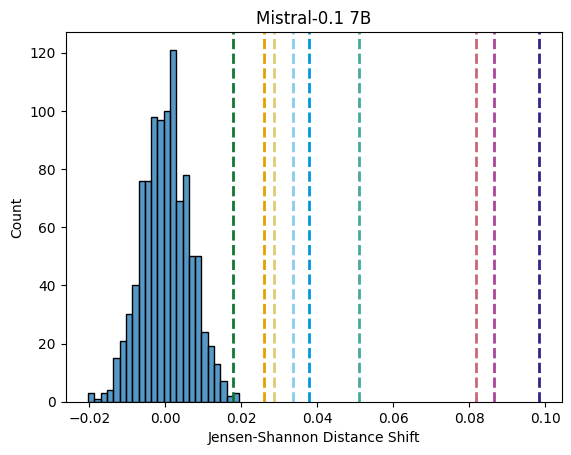

100%|██████████| 1000/1000 [01:08<00:00, 14.64it/s]


mistralai-mistral-7b-v0.3


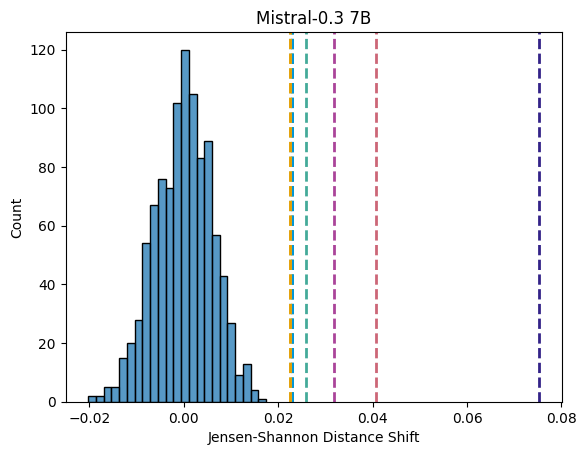

,model,choice-ent_obs,choice-ent_p,total-ent_obs,total-ent_p,top-k-ent-5_obs,top-k-ent-5_p,top-k-ent-10_obs,top-k-ent-10_p,top-k-ent-25_obs,top-k-ent-25_p,top-k-ent-50_obs,top-k-ent-50_p,top-k-ent-100_obs,top-k-ent-100_p,top-p-ent-0.95_obs,top-p-ent-0.95_p,top-p-ent-0.9_obs,top-p-ent-0.9_p
0,meta-llama-llama-3.1-8b-instruct,0.098064,0.0,0.082403,0.000,0.107598,0.0,0.097488,0.0,0.090552,0.0,0.086485,0.0,0.083653,0.0,0.060751,0.000,0.061930,0.0
0,meta-llama-llama-3.1-8b,0.216681,0.0,0.143783,0.000,0.051593,0.0,0.141751,0.0,0.158166,0.0,0.153608,0.0,0.148494,0.0,0.159775,0.000,0.088984,0.0
0,meta-llama-llama-3.2-1b-instruct,0.092681,0.0,0.016766,0.005,0.149077,0.0,0.148248,0.0,0.112001,0.0,0.082108,0.0,0.060135,0.0,0.112376,0.000,0.132106,0.0
0,meta-llama-llama-3.2-1b,0.054948,0.0,0.033834,0.000,0.054856,0.0,0.068896,0.0,0.061437,0.0,0.052770,0.0,0.046212,0.0,0.016382,0.004,0.026566,0.0
0,meta-llama-llama-3.2-3b-instruct,0.030636,0.0,0.019784,0.000,0.042590,0.0,0.039525,0.0,0.034616,0.0,0.030733,0.0,0.028438,0.0,0.046466,0.000,0.038210,0.0
0,meta-llama-llama-3.2-3b,0.149996,0.0,0.040007,0.000,0.093500,0.0,0.126255,0.0,0.098642,0.0,0.071412,0.0,0.054511,0.0,0.076349,0.000,0.118422,0.0
0,mistralai-mistral-7b-instruct-v0.1,0.059649,0.0,-0.122491,0.000,-0.127314,0.0,-0.126197,0.0,-0.125097,0.0,-0.124069,0.0,-0.123458,0.0,-0.099091,0.000,0.052175,0.0
0,mistralai-mistral-7b-instruct-v0.3,0.091381,0.0,0.084677,0.000,0.087621,0.0,0.085151,0.0,0.083293,0.0,0.083967,0.0,0.083414,0.0,0.062931,0.000,0.021828,0.0
0,mistralai-mistral-7b-v0.1,0.098404,0.0,0.017822,0.003,0.050972,0.0,0.037871,0.0,0.033489,0.0,0.028705,0.0,0.025915,0.0,0.081712,0.000,0.086502,0.0
0,mistralai-mistral-7b-v0.3,0.075266,0.0,0.022877,0.000,0.025897,0.0,0.023019,0.0,0.022415,0.0,0.022565,0.0,0.022528,0.0,0.040670,0.000,0.031895,0.0


In [ ]:
def resample_distribution(dist):
    n = int(sum(dist))
    return np.random.multinomial(n, dist)

def normalize(counts):
    counts = np.asarray(counts)
    if counts.sum() == 0:
        return counts
    else:
        return counts / counts.sum()

def js_distance(p, q):
    p = normalize(p)
    q = normalize(q)
    return jensenshannon(p, q)

def permutation_p_value(ref_list, obs):
    return len([i for i in ref_list if abs(obs) <= i]) / len(ref_list)

def stat_test(df, n_iterations=10000, seed=757):
    def get_T(binned_df):
        high_df = binned_df[binned_df['bin'] == 'high']
        low_df  = binned_df[binned_df['bin'] == 'low']

        p       = normalize(high_df[['A-mod', 'B-mod', 'C-mod', 'D-mod']].to_numpy().flatten())
        p_prime = normalize(high_df[['A-act', 'B-act', 'C-act', 'D-act']].to_numpy().flatten())
        q       = normalize(low_df[['A-mod', 'B-mod', 'C-mod', 'D-mod']].to_numpy().flatten())
        q_prime = normalize(low_df[['A-act', 'B-act', 'C-act', 'D-act']].to_numpy().flatten())

        return js_distance(p, p_prime) - js_distance(q, q_prime)

    np.random.seed(seed)

    model_map = {
        'meta-llama-llama-3.2-1b'            : 'LLaMa-3.2 1B',
        'meta-llama-llama-3.2-1b-instruct'   : 'LLaMa-3.2 1B Instruct',
        'meta-llama-llama-3.2-3b'            : 'LLaMa-3.2 3B',
        'meta-llama-llama-3.2-3b-instruct'   : 'LLaMa-3.2 3B Instruct',
        'mistralai-mistral-7b-instruct-v0.1' : 'Mistral-0.1 7B Instruct',
        'mistralai-mistral-7b-instruct-v0.3' : 'Mistral-0.3 7B Instruct',
        'mistralai-mistral-7b-v0.1'          : 'Mistral-0.1 7B',
        'mistralai-mistral-7b-v0.3'          : 'Mistral-0.3 7B',
        'meta-llama-llama-3.1-8b'            : 'LLaMa-3.1 8B',
        'meta-llama-llama-3.1-8b-instruct'   : 'LLaMa-3.1 8B Instruct',
    }

    cp = [
        '#332288',
        '#117733',
        '#44AA99',
        '#0097DE',
        '#88CCEE',
        '#DDCC77',
        '#E69F00',
        '#CC6677',
        '#AA4499',
        '#882255',
    ]

    output_df = pd.DataFrame()

    for model in df['model'].unique():
        ref_T_vals = [get_T(bin_df(df[df['model'] == model], 'reference', 'std', random_assign=True)) for _ in tqdm(range(n_iterations))]

        sns.histplot(pd.DataFrame({'T': ref_T_vals}), x='T')

        model_df = df[df['model'] == model]

        print(model)

        row_dict = {
            'model' : model
        }

        for i, measure in enumerate(calib_ent_measures):
            T_obs = get_T(bin_df(model_df, measure, 'std'))

            row_dict[f'{measure}_obs'] = T_obs
            row_dict[f'{measure}_p'] = permutation_p_value(ref_T_vals, T_obs)

            plt.axvline(x=T_obs, color=cp[i], linestyle='--', linewidth=2)

        row_df = pd.DataFrame([row_dict])
        output_df = pd.concat([output_df, row_df])

        plt.xlabel('Jensen-Shannon Distance Shift')
        plt.title(f'{model_map[model]}')

        plt.show()

    return output_df

with warnings.catch_warnings():
    warnings.simplefilter(action='ignore', category=FutureWarning)
    calib_shift_output = stat_test(mmlu_proc_df, n_iterations=1000)

calib_shift_output

In [ ]:
calib_shift_output.sort_values(by='model')

,model,choice-ent_obs,choice-ent_p,total-ent_obs,total-ent_p,top-k-ent-5_obs,top-k-ent-5_p,top-k-ent-10_obs,top-k-ent-10_p,top-k-ent-25_obs,top-k-ent-25_p,top-k-ent-50_obs,top-k-ent-50_p,top-k-ent-100_obs,top-k-ent-100_p,top-p-ent-0.95_obs,top-p-ent-0.95_p,top-p-ent-0.9_obs,top-p-ent-0.9_p
0,meta-llama-llama-3.1-8b,0.216681,0.0,0.143783,0.000,0.051593,0.0,0.141751,0.0,0.158166,0.0,0.153608,0.0,0.148494,0.0,0.159775,0.000,0.088984,0.000
0,meta-llama-llama-3.1-8b-instruct,0.098064,0.0,0.082403,0.000,0.107598,0.0,0.097488,0.0,0.090552,0.0,0.086485,0.0,0.083653,0.0,0.060751,0.000,0.061930,0.000
0,meta-llama-llama-3.2-1b,0.054948,0.0,0.033834,0.000,0.054856,0.0,0.068896,0.0,0.061437,0.0,0.052770,0.0,0.046212,0.0,0.016382,0.002,0.026566,0.000
0,meta-llama-llama-3.2-1b-instruct,0.092681,0.0,0.016766,0.009,0.149077,0.0,0.148248,0.0,0.112001,0.0,0.082108,0.0,0.060135,0.0,0.112376,0.000,0.132106,0.000
0,meta-llama-llama-3.2-3b,0.149996,0.0,0.040007,0.000,0.093500,0.0,0.126255,0.0,0.098642,0.0,0.071412,0.0,0.054511,0.0,0.076349,0.000,0.118422,0.000
0,meta-llama-llama-3.2-3b-instruct,0.030636,0.0,0.019784,0.000,0.042590,0.0,0.039525,0.0,0.034616,0.0,0.030733,0.0,0.028438,0.0,0.046466,0.000,0.038210,0.000
0,mistralai-mistral-7b-instruct-v0.1,0.059649,0.0,-0.122491,0.000,-0.127314,0.0,-0.126197,0.0,-0.125097,0.0,-0.124069,0.0,-0.123458,0.0,-0.099091,0.000,0.052175,0.000
0,mistralai-mistral-7b-instruct-v0.3,0.091381,0.0,0.084677,0.000,0.087621,0.0,0.085151,0.0,0.083293,0.0,0.083967,0.0,0.083414,0.0,0.062931,0.000,0.021828,0.001
0,mistralai-mistral-7b-v0.1,0.098404,0.0,0.017822,0.002,0.050972,0.0,0.037871,0.0,0.033489,0.0,0.028705,0.0,0.025915,0.0,0.081712,0.000,0.086502,0.000
0,mistralai-mistral-7b-v0.3,0.075266,0.0,0.022877,0.000,0.025897,0.0,0.023019,0.0,0.022415,0.0,0.022565,0.0,0.022528,0.0,0.040670,0.000,0.031895,0.000


In [ ]:
calib_shift_output.select_dtypes(include='number').abs().mean(numeric_only=True)

choice-ent_obs        0.096770
choice-ent_p          0.000000
total-ent_obs         0.058444
total-ent_p           0.001100
top-k-ent-5_obs       0.079102
top-k-ent-5_p         0.000000
top-k-ent-10_obs      0.089440
top-k-ent-10_p        0.000000
top-k-ent-25_obs      0.081971
top-k-ent-25_p        0.000000
top-k-ent-50_obs      0.073642
top-k-ent-50_p        0.000000
top-k-ent-100_obs     0.067676
top-k-ent-100_p       0.000000
top-p-ent-0.95_obs    0.075650
top-p-ent-0.95_p      0.000200
top-p-ent-0.9_obs     0.065862
top-p-ent-0.9_p       0.000100
dtype: float64

In [ ]:
calib_shift_output.mean(numeric_only=True)

choice-ent_obs        0.096770
choice-ent_p          0.000000
total-ent_obs         0.033946
total-ent_p           0.001100
top-k-ent-5_obs       0.053639
top-k-ent-5_p         0.000000
top-k-ent-10_obs      0.064201
top-k-ent-10_p        0.000000
top-k-ent-25_obs      0.056951
top-k-ent-25_p        0.000000
top-k-ent-50_obs      0.048828
top-k-ent-50_p        0.000000
top-k-ent-100_obs     0.042984
top-k-ent-100_p       0.000000
top-p-ent-0.95_obs    0.055832
top-p-ent-0.95_p      0.000200
top-p-ent-0.9_obs     0.065862
top-p-ent-0.9_p       0.000100
dtype: float64